# Measuring the thermal Sunyaev–Zel'dovich effect around DESI galaxies with ACT DR6
## A hands-on stacking analysis — from a CMB map and a galaxy catalogue to a gas optical depth

*Module 3 · N10c — a measurement companion to* **N10** *(SZ theory) and* **N10b** *(SZ prediction).*

In **N10b** we *predicted* the tSZ signal of a galaxy stack from a pressure-profile model.
Here we do the opposite: we start from **public data** — a component-separated *Compton-$y$* map and
single-frequency temperature maps from the **Atacama Cosmology Telescope (ACT) Data Release 6**, and a
spectroscopic galaxy catalogue from the **Dark Energy Spectroscopic Instrument (DESI) Data Release 1** —
and *measure* the average hot-gas signal around galaxies by **stacking**.

We work with **two galaxy samples**, and the contrast between them is part of the lesson:

- the DESI **Bright Galaxy Sample (BGS)**, flux-limited, downloaded on the fly, no randoms — the
  sample you can always get;
- the **LS10 volume-limited BGS** of Comparat et al. 2025, more massive, properly volume-limited, and
  shipping a random catalogue — the sample a survey analysis actually uses.

The second one lets us do three things the first cannot: subtract the footprint's own mean $y$,
build a null test out of the real survey geometry, and put sample variance into the error bars.

The scientific goal is to (i) extract the mean Compton-$y$ around these galaxies, (ii) understand the
foreground systematics (dust, the cosmic infrared background, radio sources) that dominate this
measurement, and (iii) convert $y$ into an estimate of the gas **optical depth** $\tau$ using a
$y$–$\tau$ scaling relation — the same quantity that the *kinematic* SZ effect measures independently.

> This is a real analysis on ~GB-scale public maps. A first run downloads the data (cached afterwards).
> The default configuration uses a **tractable subsample** so the notebook runs in minutes; a single
> switch (`FULL_RUN`) scales it to the full sample used in the literature.

### Learning objectives

By the end of this notebook you will be able to:

1. **Describe** the tSZ effect quantitatively: the Compton-$y$ parameter, the frequency-dependent
   temperature signature, and the link between $y$, gas pressure, and optical depth $\tau$.
2. **Query and load** public ACT DR6 CMB maps (with `pixell`) and a DESI DR1 BGS catalogue, and define a
   science sample the same way a survey analysis does.
3. **Implement a stacking pipeline** from scratch: sky cutouts, compensated aperture photometry (the
   "disk-minus-ring" filter), stacking, radial profiles, and jackknife error bars.
4. **Diagnose foregrounds**: use multi-frequency information (90/150/220 GHz), ILC deprojections, a
   ring-ring filter, and a radio-source cross-match to separate the tSZ signal from dust, CIB and radio.
5. **Use a random catalogue** for what it is worth: subtracting the footprint's mean signal, building a
   null test with the true survey geometry, and defining jackknife regions on the sky so the error bars
   capture sample variance and not just shot noise.
6. **Interpret** the result physically and convert $\bar y$ to an optical depth via a simulation-calibrated
   scaling relation, comparing to independent kinematic-SZ measurements — and recognise when doing so
   would be an extrapolation dressed up as a measurement.

### How to read this notebook

We keep the conventions of N10b:

- The **headline equation** of each section is boxed, $\boxed{\;\ldots\;}$, and immediately followed by a
  **Symbols:** list defining every quantity.
- 📦 **Order-of-magnitude** boxes plug in real numbers and check the power of ten — do these by hand.
- 🎓 *Concept* notes unpack anything beyond first-year physics.
- Every equation and procedure carries a citation to the article it comes from; full references, with
  working links, are collected in the next cell.

*Prerequisites:* first-year mechanics/E&M, a little thermodynamics, and the SZ basics from N10/N10b.

## References

Each link was checked to resolve to the open-access article or data product.

**Foundational tSZ physics**
- Zeldovich & Sunyaev (1969), *Ap&SS* **4**, 301 — the SZ effect.
  [ADS](https://ui.adsabs.harvard.edu/abs/1969Ap%26SS...4..301Z)
- Sunyaev & Zeldovich (1972), *Comments Astrophys. Space Phys.* **4**, 173 — the SZ distortion of the CMB.
  [ADS](https://ui.adsabs.harvard.edu/abs/1972CoASP...4..173S)
- Carlstrom, Holder & Reese (2002), *ARA&A* **40**, 643 — SZ review (Eqs. for $y$, $f(x)$, $\tau$).
  [arXiv:astro-ph/0208192](https://arxiv.org/abs/astro-ph/0208192)

**Gas pressure profiles**
- Battaglia, Bond, Pfrommer & Sievers (2012), *ApJ* **758**, 75 — the gNFW thermal-pressure fit used here.
  [arXiv:1109.3711](https://arxiv.org/abs/1109.3711)
- Battaglia (2016), *JCAP* **08**, 058 — simulation-based $\bar y$–$\bar\tau$ scaling relation (our Eq. 14).
  [arXiv:1607.02442](https://arxiv.org/abs/1607.02442)

**Aperture-photometry stacking of ACT × galaxies (method we follow)**
- Vavagiakis et al. (2021), *PRD* **104**, 043503 — tSZ/kSZ around SDSS galaxies with ACT (disk-ring AP).
  [arXiv:2101.08373](https://arxiv.org/abs/2101.08373)
- Schaan et al. (2021), *PRD* **103**, 063513 — kSZ; the compensated-aperture-photometry filter.
  [arXiv:2009.05557](https://arxiv.org/abs/2009.05557)
- Amodeo et al. (2021), *PRD* **103**, 063514 — tSZ gas thermodynamics from the same stacks.
  [arXiv:2009.05558](https://arxiv.org/abs/2009.05558)
- Liu et al. (2025), *PRD* **112**, 083561 — ACT DR6 × DESI LRG tSZ; the 220 GHz dust removal & ring-ring test.
  [arXiv:2502.08850](https://arxiv.org/abs/2502.08850)

**Maps, catalogues & software (the public data)**
- Coulton et al. (2024), *PRD* **109**, 063530 — ACT DR6 component-separated (ILC) Compton-$y$ maps.
  [arXiv:2307.01258](https://arxiv.org/abs/2307.01258)
- Naess et al. (2025), *JCAP* **2025**, 061 — ACT DR6 maps (single-frequency co-adds).
  [arXiv:2503.14451](https://arxiv.org/abs/2503.14451)
- ACT data on LAMBDA — [ACT DR6 Compton-$y$](https://lambda.gsfc.nasa.gov/product/act/actadv_dr6_compton_maps_info.html) ·
  [ACT DR6.02 maps](https://lambda.gsfc.nasa.gov/product/act/act_dr6.02/act_dr6.02_maps_info.html)
- `pixell` (Naess, Madhavacheril & Hasselfield) — CAR-map toolkit.
  [ascl:2102.003](https://ascl.net/2102.003) · [github](https://github.com/simonsobs/pixell)
- Gallardo et al. (2025), *RNAAS* **9**, 284 — `iskay2` aperture-photometry code (independent implementation).
  [arXiv:2510.20715](https://arxiv.org/abs/2510.20715)

**DESI galaxies**
- DESI Collaboration (2025), *AJ* **171**, 285 — DESI Data Release 1.
  [arXiv:2503.14745](https://arxiv.org/abs/2503.14745)
- Siudek et al. (2024), *A&A* **691**, A308 — value-added physical properties (stellar masses) for DESI galaxies.
  [arXiv:2409.19066](https://arxiv.org/abs/2409.19066)
- FastSpecFit (Moustakas et al.) — DESI DR1 spectrophotometric value-added catalogue (`LOGMSTAR`).
  [docs](https://fastspecfit.readthedocs.io) · [DESI DR1 VAC](https://data.desi.lbl.gov/doc/releases/dr1/vac/fastspecfit/)

**Optical depth: kinematic-SZ comparison & simulations**
- Hadzhiyska et al. (2026), *PRD* **113**, 063565 — pairwise **kSZ** optical depths for the **DESI BGS** sample.
  [arXiv:2510.14135](https://arxiv.org/abs/2510.14135)
- Gong et al. (2026), *PRD* **113**, 063538 — pairwise kSZ for DESI LRGs (companion).
  [arXiv:2511.23417](https://arxiv.org/abs/2511.23417)
- Davé et al. (2019), *MNRAS* **486**, 2827 — the **SIMBA** simulation used to calibrate the BGS $y$–$\tau$ relation.
  [arXiv:1901.10203](https://arxiv.org/abs/1901.10203)
- Hand et al. (2012), *PRL* **109**, 041101 — first pairwise-kSZ detection.
  [arXiv:1203.4219](https://arxiv.org/abs/1203.4219)

**Foreground catalogue**
- Condon et al. (1998), *AJ* **115**, 1693 — the NVSS 1.4 GHz radio-source catalogue (VizieR `VIII/65`).
  [ADS](https://ui.adsabs.harvard.edu/abs/1998AJ....115.1693C)

In [1]:
# --- Imports and global setup -------------------------------------------------
import os, warnings, urllib.request
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import astropy.io.fits as fits
import astropy.units as u
from astropy import constants as const
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad, cumulative_trapezoid
from scipy.interpolate import interp1d

from pixell import enmap, reproject, utils   # ACT maps live in the CAR pixelisation

# physical constants (SI-ish, values pulled from astropy = CODATA)
sigma_T = const.sigma_T          # Thomson cross-section
m_e     = const.m_e
c       = const.c
k_B     = const.k_B
h_planck = const.h.value
T_cmb   = 2.7255 * u.K           # Fixsen 2009 CMB monopole
T_cmb_uK = T_cmb.to_value(u.uK)

plt.rcParams.update({'figure.figsize': (9, 5.4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3, 'image.cmap': 'RdBu_r'})
np.random.seed(42)
print('Setup ready — pixell', __import__('pixell').__version__,
      '| numpy', np.__version__)

Setup ready — pixell 0.31.10 | numpy 2.4.6


# Part 1 — A flexible query for the public data

Every stacking analysis begins the same way: **decide what data you need, fetch it, and define a clean
sample.** We do that first, in one place, so the rest of the notebook is pure physics.

We need three ingredients:

| Ingredient | Product | Why |
|---|---|---|
| CMB maps | **ACT DR6 + *Planck*** Compton-$y$ (ILC) and single-frequency co-adds (90/150/220 GHz) | carry the tSZ signal |
| Galaxies | **DESI DR1 Bright Galaxy Sample** (with stellar masses) | the objects we stack on |
| Radio sources | **NVSS** 1.4 GHz catalogue | to flag radio contamination |

All are **public**. The maps are stored in the *plate carrée* (CAR) pixelisation and read with `pixell`
(Naess et al.; Coulton et al. 2024; Naess et al. 2025). The galaxies come from the DESI DR1 value-added
catalogues (DESI 2025; Siudek et al. 2024).

In [2]:
# --- CONFIG: the single place that controls cost vs. fidelity --------------------
CONFIG = dict(
    CACHE       = 'data/sz_actxdesi/cache',  # local cache for maps + catalogues
    MAX_SOURCES = 30_000,     # cap on stacked galaxies (None -> full sample ~1.6M)
    MASS_MIN    = 10.0,       # log10(M*/Msun) lower cut  (defines the "full" BGS sample)
    FOOTPRINT   = None,       # optional (ra_min, ra_max, dec_min, dec_max) in degrees
    N_JACKKNIFE = 200,        # jackknife subsamples for error bars (literature: 2000)
    APERTURE    = 2.7,        # BGS disk-minus-ring aperture radius R_AP  [arcmin]
    FASTSPEC_HP = [6],        # DESI FastSpecFit nside=1 bright HEALPix pixels to load
    AUTO_DOWNLOAD = True,     # fetch missing files (first run) vs. use cache only
    FULL_RUN    = False,      # True -> paper-scale settings (large download + hours)
)
if CONFIG['FULL_RUN']:
    CONFIG.update(MAX_SOURCES=None, N_JACKKNIFE=2000, FASTSPEC_HP=list(range(12)))

os.makedirs(CONFIG['CACHE'], exist_ok=True)
print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:14s} = {v}')
print('\\nTip: set CONFIG["FULL_RUN"]=True (and re-run) to reproduce paper-level S/N.')

Configuration:
  CACHE          = data/sz_actxdesi/cache
  MAX_SOURCES    = 30000
  MASS_MIN       = 10.0
  FOOTPRINT      = None
  N_JACKKNIFE    = 200
  APERTURE       = 2.7
  FASTSPEC_HP    = [6]
  AUTO_DOWNLOAD  = True
  FULL_RUN       = False
\nTip: set CONFIG["FULL_RUN"]=True (and re-run) to reproduce paper-level S/N.


In [3]:
# --- A robust, resumable downloader ---------------------------------------------
def download(url, dest, min_bytes=1000, quiet=False):
    '''Stream `url` to `dest` with resume; skip if already present. Returns path or None.'''
    if os.path.exists(dest) and os.path.getsize(dest) > min_bytes:
        return dest
    if not CONFIG['AUTO_DOWNLOAD']:
        if not quiet: print('  [skip download, AUTO_DOWNLOAD=False]', os.path.basename(dest))
        return None
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    part = dest + '.part'
    have = os.path.getsize(part) if os.path.exists(part) else 0
    req = urllib.request.Request(url, headers={'Range': f'bytes={have}-'} if have else {})
    try:
        with urllib.request.urlopen(req, timeout=120) as r, open(part, 'ab') as f:
            total = have + (int(r.headers.get('Content-Length', 0)) or 0)
            while True:
                chunk = r.read(8 << 20)
                if not chunk: break
                f.write(chunk)
                if not quiet and total:
                    print(f'  {os.path.basename(dest)} {os.path.getsize(part)/total*100:5.1f}%', end='\\r')
    except Exception as e:
        print('  download failed:', e); return None
    os.replace(part, dest)
    if not quiet: print('  downloaded', os.path.basename(dest), f'{os.path.getsize(dest)/1e9:.2f} GB')
    return dest

## 1.1 ACT DR6 maps

ACT observed the millimetre sky at 98, 150 and 220 GHz; combined with *Planck* these give
**single-frequency co-added temperature maps** ("f090", "f150", "f220"). Separately, a **needlet internal
linear combination (NILC)** of all frequencies isolates the **Compton-$y$** signal (Coulton et al. 2024).
The NILC pipeline also produces *deprojected* variants that null the cosmic-infrared-background (CIB)
spectral shape ("CIB-deprojected") or, additionally, the first derivative of that shape with respect to
the CIB spectral index ("d$\beta$-deprojected"). Comparing these tells us how much the result depends on
foreground modelling.

🎓 *Concept — internal linear combination.* An ILC forms a weighted sum of the frequency maps,
$\hat y=\sum_\nu w_\nu\,m_\nu$, choosing weights that (a) give unit response to the known tSZ spectrum and
(b) minimise the output variance. "Deprojecting" a component adds the constraint that its spectrum gets
**zero** response, at the cost of slightly higher noise.

We only ever need the **temperature** plane of the single-frequency maps, so we stream just that plane
(1.8 GB instead of 5.3 GB per frequency).

In [4]:
# --- Stream only the temperature (Stokes I) plane of a (3,ny,nx) CAR co-add -----
def _header_from(url):
    req = urllib.request.Request(url, headers={'Range': 'bytes=0-524287'})
    raw = urllib.request.urlopen(req, timeout=120).read()
    for i in range(0, len(raw), 80):
        if raw[i:i+3] == b'END' and raw[i+3:i+80].strip() == b'':
            hlen = ((i // 2880) + 1) * 2880
            return hlen, fits.Header.fromstring(raw[:hlen].decode('latin1'))
    raise ValueError('FITS header END not found')

def stream_T_plane(url, dest):
    '''Download only plane 0 (temperature) of a TQU CAR map -> a 2D FITS pixell can read.'''
    if os.path.exists(dest) and os.path.getsize(dest) > 1_000_000:
        return dest
    if not CONFIG['AUTO_DOWNLOAD']:
        return None
    hlen, hdr = _header_from(url)
    n1, n2 = hdr['NAXIS1'], hdr['NAXIS2']
    nbytes = n1 * n2 * (abs(hdr['BITPIX']) // 8)
    part = dest + '.part'
    have = os.path.getsize(part) if os.path.exists(part) else 0
    with open(part, 'ab') as f:
        pos = have
        while pos < nbytes:
            hi = min(pos + (64 << 20), nbytes) - 1
            req = urllib.request.Request(url, headers={'Range': f'bytes={hlen+pos}-{hlen+hi}'})
            f.write(urllib.request.urlopen(req, timeout=120).read())
            pos = hi + 1
            print(f'  {os.path.basename(dest)} {pos/nbytes*100:5.1f}%', end='\\r')
    arr = np.fromfile(part, dtype='>f4', count=n1*n2).reshape(n2, n1).astype(np.float32)
    h2 = hdr.copy(); h2['NAXIS'] = 2
    for k in list(h2.keys()):
        if k[-1] == '3' and k[:-1] in ('NAXIS','CTYPE','CRPIX','CRVAL','CDELT','CUNIT'):
            del h2[k]
    fits.PrimaryHDU(arr, h2).writeto(dest, overwrite=True); os.remove(part)
    print('\\n  wrote', os.path.basename(dest)); return dest

In [5]:
# --- ACT map registry (verified public LAMBDA URLs) -----------------------------
_LNILC = 'https://lambda.gsfc.nasa.gov/data/act/nilc/published'
_LMAP  = 'https://lambda.gsfc.nasa.gov/data/act/maps/published'
_LY    = 'https://lambda.gsfc.nasa.gov/data/suborbital/ACT/ACT_adv/Compton_y_maps'

ACT = {   # name -> dict(url, kind, dest, unit, nu_GHz, fwhm_arcmin)
 'ymap'      : dict(url=f'{_LNILC}/act-planck_dr6.02_nilc_ComptonY.fits',
                    kind='ymap', unit='y',  nu=None, fwhm=1.6),
 'ymap_cib'  : dict(url=f'{_LNILC}/act-planck_dr6.02_nilc_ComptonY_deproj_cib_1.0_10.7.fits',
                    kind='ymap', unit='y',  nu=None, fwhm=1.6),
 'ymap_dbeta': dict(url=f'{_LNILC}/act-planck_dr6.02_nilc_ComptonY_deproj_cib_cibdBeta_1.0_10.7.fits',
                    kind='ymap', unit='y',  nu=None, fwhm=1.6),
 'ymap_cib_b16': dict(url=f'{_LNILC}/act-planck_dr6.02_nilc_ComptonY_deproj_cib_1.6_10.7.fits',
                    kind='ymap', unit='y',  nu=None, fwhm=1.6),
 'ymap_cib_T24': dict(url=f'{_LNILC}/act-planck_dr6.02_nilc_ComptonY_deproj_cib_1.0_24.0.fits',
                    kind='ymap', unit='y',  nu=None, fwhm=1.6),
 'f090'      : dict(url=f'{_LMAP}/act-planck_dr6.02_coadd_AA_daynight_f090_map.fits',
                    kind='coadd', unit='uK', nu=97.4, fwhm=2.1),
 'f150'      : dict(url=f'{_LMAP}/act-planck_dr6.02_coadd_AA_daynight_f150_map.fits',
                    kind='coadd', unit='uK', nu=149.6, fwhm=1.4),
 'f220'      : dict(url=f'{_LMAP}/act-planck_dr6.02_coadd_AA_daynight_f220_map.fits',
                    kind='coadd', unit='uK', nu=225.7, fwhm=1.0),
}
for k, v in ACT.items():
    v['dest'] = os.path.join(CONFIG['CACHE'],
                             ('coadd_%s_T.fits' % k) if v['kind']=='coadd' else os.path.basename(v['url']))

_MAPCACHE = {}
def load_map(name):
    '''Return the pixell enmap for `name`, downloading/streaming if needed; None if unavailable.'''
    if name in _MAPCACHE: return _MAPCACHE[name]
    v = ACT[name]
    path = stream_T_plane(v['url'], v['dest']) if v['kind']=='coadd' else download(v['url'], v['dest'])
    if path is None or not os.path.exists(path):
        print(f'  [{name}] not available (download it to enable the figures that use it)')
        _MAPCACHE[name] = None; return None
    try:
        m = enmap.read_map(path)
    except Exception as e:
        print(f'  [{name}] could not read {os.path.basename(path)} ({type(e).__name__}); skipping')
        _MAPCACHE[name] = None; return None
    if m.ndim == 3: m = m[0]
    _MAPCACHE[name] = m
    print(f'  [{name}] loaded  shape={m.shape}  ({v["unit"]})')
    return m

# fetch the ILC beam transfer function (small) for the y-map
download(f'{_LY}/ilc_beam.txt', os.path.join(CONFIG['CACHE'], 'ilc_beam.txt'), quiet=True)
print('ACT registry ready:', list(ACT))

ACT registry ready: ['ymap', 'ymap_cib', 'ymap_dbeta', 'ymap_cib_b16', 'ymap_cib_T24', 'f090', 'f150', 'f220']


## 1.2 The DESI Bright Galaxy Sample

The BGS is DESI's low-redshift, magnitude-limited galaxy sample ($r<19.5$, median $z\approx0.2$). We read
the **FastSpecFit** value-added catalogue, which provides a stellar mass (`LOGMSTAR`) for every DESI
galaxy from a joint fit to its spectrum and photometry. The catalogue is partitioned into large
`nside=1` HEALPix pixels; we load the pixel(s) in `CONFIG['FASTSPEC_HP']`.

Following the analysis we reproduce, the **full sample** is every BGS galaxy with
$\log_{10}(M_*/M_\odot)>10$, and it is further split into six *cumulative* stellar-mass bins,
$\log_{10}(M_*/M_\odot)>\{10,10.25,10.5,10.75,11,11.25\}$.

In [6]:
# --- Load DESI DR1 BGS galaxies with stellar masses from FastSpecFit ------------
_FSBASE = 'https://data.desi.lbl.gov/public/dr1/vac/dr1/fastspecfit/iron/v3.0/catalogs'

def _read_cols(path, want):
    '''Pull each requested column from whichever (row-matched) HDU contains it.'''
    out = {}
    with fits.open(path, memmap=True) as hd:
        for h in hd[1:]:
            if not hasattr(h, 'columns'): continue
            names = {c.upper(): c for c in h.columns.names}
            for w in want:
                if w in names and w not in out:
                    out[w] = np.asarray(h.data[names[w]])
    return out

def load_bgs():
    want = ['RA','DEC','Z','LOGMSTAR','ZWARN','SPECTYPE','BGS_TARGET']
    cols = {k: [] for k in want}
    for hp in CONFIG['FASTSPEC_HP']:
        fn = f'fastspec-iron-main-bright-nside1-hp{hp:02d}.fits'
        path = download(f'{_FSBASE}/{fn}', os.path.join(CONFIG['CACHE'], fn))
        if path is None: continue
        d = _read_cols(path, want)
        n = len(d.get('RA', []))
        for k in want:
            cols[k].append(d[k] if k in d else np.full(n, np.nan if k!='SPECTYPE' else ''))
    if not cols['RA']:
        raise RuntimeError('No FastSpecFit file available — set AUTO_DOWNLOAD=True.')
    cat = {k: np.concatenate(v) for k, v in cols.items()}
    # --- selection: bright-time galaxies with a good redshift and a stellar mass ---
    m  = np.isfinite(cat['LOGMSTAR']) & (cat['LOGMSTAR'] > CONFIG['MASS_MIN'])
    m &= np.isfinite(cat['Z']) & (cat['Z'] > 0.01) & (cat['Z'] < 0.6)
    if np.isfinite(cat['ZWARN']).any():   m &= (cat['ZWARN'] == 0)
    spec = np.char.strip(cat['SPECTYPE'].astype(str))
    if (spec != '').any():                m &= (spec == 'GALAXY')
    if np.isfinite(cat['BGS_TARGET']).any():
        m &= (cat['BGS_TARGET'].astype('int64') & 0b10) != 0   # BGS_BRIGHT bit
    cat = {k: v[m] for k, v in cat.items()}
    print(f'BGS galaxies with logM*>{CONFIG["MASS_MIN"]}: {m.sum():,}  '
          f'(from HEALPix {CONFIG["FASTSPEC_HP"]})')
    return cat

bgs = load_bgs()

BGS galaxies with logM*>10.0: 681,519  (from HEALPix [6])


### Restrict to the ACT footprint and (optionally) subsample

A galaxy only helps if the CMB map actually covers it. We load the fiducial $y$-map and keep galaxies
that fall on valid pixels (this defines our effective footprint). We then optionally cap the sample size
for a fast run. **This subsampling only lowers the signal-to-noise — it does not bias the measurement.**

In [7]:
# --- keep galaxies inside the ACT footprint, then subsample ---------------------
def sky_coords(ra, dec):
    return np.deg2rad(np.stack([dec, ra], axis=0))   # pixell wants [dec, ra] in radians

ymap0 = load_map('ymap')
if ymap0 is not None:
    val = ymap0.at(sky_coords(bgs['RA'], bgs['DEC']), order=0)   # map value at each galaxy
    covered = np.isfinite(val) & (val != 0.0)
else:
    covered = np.ones(len(bgs['RA']), bool)               # no map yet: keep all
if CONFIG['FOOTPRINT'] is not None:
    r0, r1, d0, d1 = CONFIG['FOOTPRINT']
    covered &= (bgs['RA']>=r0)&(bgs['RA']<=r1)&(bgs['DEC']>=d0)&(bgs['DEC']<=d1)
bgs = {k: v[covered] for k, v in bgs.items()}
print(f'inside ACT footprint: {covered.sum():,} galaxies')

if CONFIG['MAX_SOURCES'] and len(bgs['RA']) > CONFIG['MAX_SOURCES']:
    sel = np.random.choice(len(bgs['RA']), CONFIG['MAX_SOURCES'], replace=False)
    bgs = {k: v[sel] for k, v in bgs.items()}
    print(f'subsampled to {len(bgs["RA"]):,} galaxies for a fast run '
          f'(set MAX_SOURCES=None for the full sample)')

# From here on a "sample" is a dict of columns plus a little metadata. `key` identifies the
# sample in the stack cache (see section 6), `label` is what appears in legends, and the
# `rand_*`/`jk` entries are filled in only by samples that ship a random catalogue.
BGS = bgs
BGS['key']      = 'bgs'
BGS['label']    = 'DESI BGS'
BGS['rand_ra']  = None          # DESI BGS ships no randoms with this notebook
BGS['rand_dec'] = None
BGS['rand_jk']  = None
BGS['jk']       = None          # -> jackknife() falls back to permutation groups

# cumulative stellar-mass bins (as in the analysis we reproduce)
MASS_CUTS = [10.0, 10.25, 10.5, 10.75, 11.0, 11.25]
BINS = {f'M>{mc:g}': (bgs['LOGMSTAR'] > mc) for mc in MASS_CUTS}
print('\nsample :  <z> = %.3f   <logM*> = %.2f' % (bgs['Z'].mean(), bgs['LOGMSTAR'].mean()))
for name, mask in BINS.items():
    print(f'  {name:9s}: {mask.sum():7,d} galaxies,  <z>={bgs["Z"][mask].mean():.3f}')

  [ymap] loaded  shape=(10320, 43200)  (y)
inside ACT footprint: 659,121 galaxies


subsampled to 30,000 galaxies for a fast run (set MAX_SOURCES=None for the full sample)

sample :  <z> = 0.243   <logM*> = 10.69
  M>10     :  30,000 galaxies,  <z>=0.243
  M>10.25  :  25,987 galaxies,  <z>=0.255
  M>10.5   :  20,174 galaxies,  <z>=0.271
  M>10.75  :  13,273 galaxies,  <z>=0.293
  M>11     :   6,587 galaxies,  <z>=0.317
  M>11.25  :   1,980 galaxies,  <z>=0.346


## 1.3 A second sample: the LS10 volume-limited BGS

The DESI sample above is convenient — it downloads itself — but it has three weaknesses that
matter for a tSZ measurement, and all three are worth naming before we fix them:

1. **It is not volume-limited.** The `LOGMSTAR > 10` cut is applied to a flux-limited catalogue,
   so the mean stellar mass drifts with redshift and the mass bins mix populations.
2. **It runs out of massive galaxies.** Above $\log_{10}M_*\simeq11.25$ the DESI BGS bins hold too
   few galaxies to measure anything, and the tSZ signal grows steeply with mass — so we are
   stopping exactly where the physics gets interesting.
3. **It has no randoms.** Without a random catalogue we cannot subtract the mean $y$ of the
   footprint, our null test has to invent uniform positions in a RA/Dec box that ignores the
   survey geometry, and our error bars can only capture shot noise.

So we add a second sample: the **LS10 volume-limited BGS** of
[Comparat et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv250203426C/abstract), selected
from Legacy Survey DR10 photometry with LePhare stellar masses. We take the most massive of the
nine volume-limited samples, $11.5 < \log_{10}(M_*/M_\odot) < 12.0$ over $0.05 < z < 0.35$
(120,882 galaxies), and it ships a matched random catalogue with the true survey geometry.

**A caveat to keep in view.** DESI `LOGMSTAR` comes from FastSpecFit; LS10 `LPH_MASS_BEST` comes
from LePhare. These are different stellar-mass estimators fit to different photometry, and
systematic offsets of ~0.1–0.2 dex between them are expected. When we put both on the same mass
axis in Figures 12 and 17, the LS10 point's *horizontal* placement carries that systematic. We
plot it anyway — the alternative is not to compare at all — but we do not pretend the two mass
scales are the same measurement.

In [8]:
# --- Load the LS10 volume-limited BGS sample + its randoms ---------------------
LS10_DIR  = '/home/comparat/data/legacysurvey/dr10/sweep/BGS_VLIM_Mstar'
LS10_STEM = 'LS10_VLIM_ANY_11.5_Mstar_12.0_0.05_z_0.35_N_0120882'
LS10_MASS_CUT  = 11.5      # the sample's own threshold, for the Fig. 12/17 mass axis
N_SKY_REGIONS  = 100       # jackknife patches drawn from the random catalogue
N_RAND_MAX     = 60_000    # randoms to stack (runtime; the file holds 606,304)

def _fits_cols(path, cols):
    with fits.open(path, memmap=True) as hd:
        d = hd[1].data
        return {k: np.asarray(d[k], dtype=float) for k in cols}

def _sky_regions(ra, dec, n_regions, seed=0):
    '''k-means patches on the unit sphere. Returns a function assigning a region to any (ra,dec).
       We cluster in 3D so the patches stay compact across the RA=0/360 wrap and near the poles,
       which a naive (RA, Dec) grid gets badly wrong for a footprint like this one.'''
    from scipy.cluster.vq import kmeans2
    from scipy.spatial import cKDTree
    def xyz(r, d):
        r, d = np.deg2rad(r), np.deg2rad(d)
        return np.stack([np.cos(d)*np.cos(r), np.cos(d)*np.sin(r), np.sin(d)], axis=1)
    rng = np.random.default_rng(seed)
    P = xyz(ra, dec)
    sub = P[rng.choice(len(P), min(len(P), 50_000), replace=False)]
    cen, _ = kmeans2(sub, n_regions, minit='++', seed=seed)
    tree = cKDTree(cen)
    return lambda r, d: tree.query(xyz(r, d))[1]

def load_ls10():
    dat = _fits_cols(f'{LS10_DIR}/{LS10_STEM}_DATA.fits',
                     ['RA', 'DEC', 'BEST_Z', 'LPH_MASS_BEST'])
    rnd = _fits_cols(f'{LS10_DIR}/{LS10_STEM}_RAND.fits', ['RA', 'DEC', 'Z'])
    # rename to the column names the rest of the notebook already speaks
    s = dict(RA=dat['RA'], DEC=dat['DEC'], Z=dat['BEST_Z'], LOGMSTAR=dat['LPH_MASS_BEST'])
    print(f'LS10 {LS10_STEM.split("_N_")[0]}: {len(s["RA"]):,} galaxies, {len(rnd["RA"]):,} randoms')

    # same ACT footprint cut as the BGS sample, applied to galaxies AND randoms
    def in_act(ra, dec):
        if ymap0 is None: return np.ones(len(ra), bool)
        v = ymap0.at(sky_coords(ra, dec), order=0)
        return np.isfinite(v) & (v != 0.0)
    keep = in_act(s['RA'], s['DEC'])
    s = {k: v[keep] for k, v in s.items()}
    rkeep = in_act(rnd['RA'], rnd['DEC'])
    rra, rdec = rnd['RA'][rkeep], rnd['DEC'][rkeep]
    print(f'  inside ACT footprint: {keep.sum():,} galaxies ({100*keep.mean():.1f}%), '
          f'{rkeep.sum():,} randoms ({100*rkeep.mean():.1f}%)')

    # jackknife patches from the random density field, BEFORE subsampling, so the patches
    # trace the true footprint rather than the galaxies we happen to keep
    assign = _sky_regions(rra, rdec, N_SKY_REGIONS, seed=0)
    s['jk'] = assign(s['RA'], s['DEC'])

    if CONFIG['MAX_SOURCES'] and len(s['RA']) > CONFIG['MAX_SOURCES']:
        sel = np.random.choice(len(s['RA']), CONFIG['MAX_SOURCES'], replace=False)
        s = {k: v[sel] for k, v in s.items()}
        print(f'  subsampled to {len(s["RA"]):,} galaxies for a fast run')
    if len(rra) > N_RAND_MAX:
        rsel = np.random.choice(len(rra), N_RAND_MAX, replace=False)
        rra, rdec = rra[rsel], rdec[rsel]
    s['rand_ra'], s['rand_dec'] = rra, rdec
    s['rand_jk'] = assign(rra, rdec)
    s['key']   = 'ls10'
    s['label'] = 'LS10 M*>11.5'
    return s

LS10 = load_ls10()
print(f'\nLS10 sample :  <z> = {LS10["Z"].mean():.3f}   <logM*> = {LS10["LOGMSTAR"].mean():.2f}   '
      f'N = {len(LS10["RA"]):,}  ({len(LS10["rand_ra"]):,} randoms, '
      f'{len(np.unique(LS10["jk"]))} jackknife patches)')
print(f'BGS  sample :  <z> = {BGS["Z"].mean():.3f}   <logM*> = {BGS["LOGMSTAR"].mean():.2f}   '
      f'N = {len(BGS["RA"]):,}')
print('\nThe LS10 galaxies are ~0.9 dex more massive and sit at roughly twice the mean redshift.')

LS10 LS10_VLIM_ANY_11.5_Mstar_12.0_0.05_z_0.35: 120,882 galaxies, 606,304 randoms


  inside ACT footprint: 101,375 galaxies (83.9%), 509,853 randoms (84.1%)


  subsampled to 30,000 galaxies for a fast run

LS10 sample :  <z> = 0.262   <logM*> = 11.62   N = 30,000  (60,000 randoms, 100 jackknife patches)
BGS  sample :  <z> = 0.243   <logM*> = 10.69   N = 30,000

The LS10 galaxies are ~0.9 dex more massive and sit at roughly twice the mean redshift.


## 1.3 What does the sample look like? (Figures 1 & 2)

Two standard sanity plots: **where** the galaxies are on the CMB map (footprint) and their **redshift
distribution** $n(z)$. These reproduce Figs. 1 and 2 of the analysis, for the BGS sample.

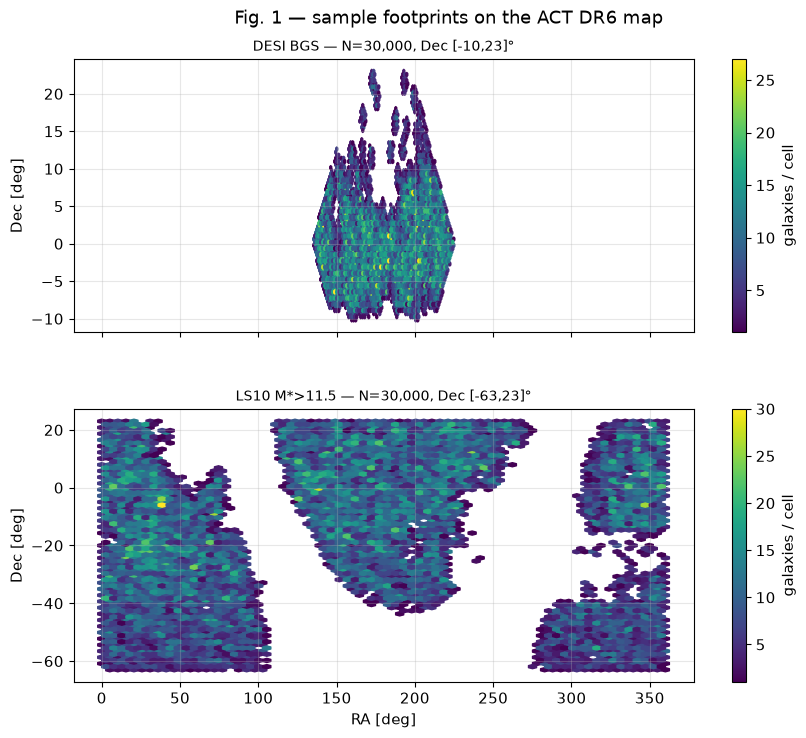

30,000 BGS galaxies span RA [135,225]°, Dec [-10,23]° — one nside=1 HEALPix pixel.
30,000 LS10 galaxies span the full LS10 footprint clipped to ACT: Dec [-63,23]° — much wider, and reaching south of the NVSS radio catalogue (Dec > -40°), which we handle in section 13.


In [9]:
# --- Figure 1: footprints of both samples (galaxies on valid ACT pixels) -------
# (These galaxies passed the ACT-coverage cut above, so this IS the ACTxDESI overlap.)
fig, axes = plt.subplots(2, 1, figsize=(10, 7.6), sharex=True)
for ax, s in zip(axes, [BGS, LS10]):
    hb = ax.hexbin(s['RA'], s['DEC'], gridsize=70, cmap='viridis', mincnt=1)
    plt.colorbar(hb, ax=ax, label='galaxies / cell')
    ax.set_ylabel('Dec [deg]')
    ax.set_title(f'{s["label"]} — N={len(s["RA"]):,}, '
                 f'Dec [{s["DEC"].min():.0f},{s["DEC"].max():.0f}]°', fontsize=10)
axes[1].set_xlabel('RA [deg]')
fig.suptitle('Fig. 1 — sample footprints on the ACT DR6 map', y=0.995)
fig.subplots_adjust(top=0.93, hspace=0.28)
plt.savefig('sza_fig01_footprint.png', dpi=130); plt.show()
print(f'{len(BGS["RA"]):,} BGS galaxies span RA [{BGS["RA"].min():.0f},{BGS["RA"].max():.0f}]°, '
      f'Dec [{BGS["DEC"].min():.0f},{BGS["DEC"].max():.0f}]° — one nside=1 HEALPix pixel.')
print(f'{len(LS10["RA"]):,} LS10 galaxies span the full LS10 footprint clipped to ACT: '
      f'Dec [{LS10["DEC"].min():.0f},{LS10["DEC"].max():.0f}]° — much wider, and reaching south '
      f'of the NVSS radio catalogue (Dec > -40°), which we handle in section 13.')

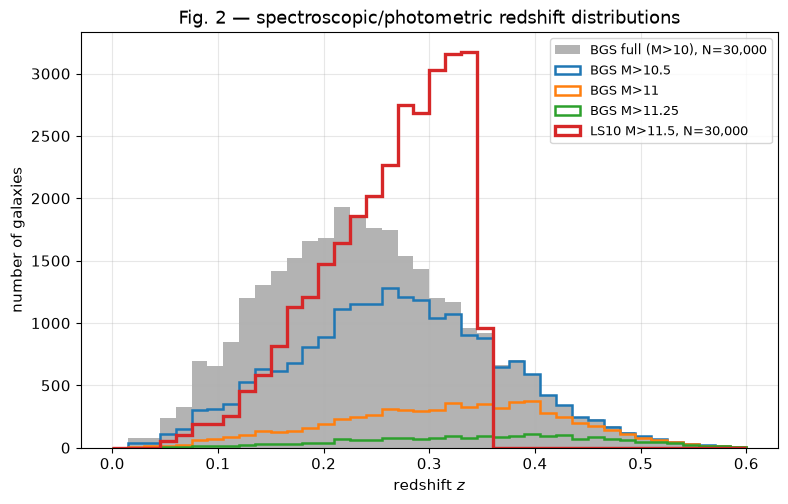

Within BGS the mean redshift increases with the mass threshold — more massive galaxies are seen further out. The LS10 n(z) has the flat-topped shape of a volume-limited selection: it is cut at z=0.35 by construction, not by the flux limit.


In [10]:
# --- Figure 2: redshift distribution of both samples ---------------------------
fig, ax = plt.subplots()
zb = np.linspace(0, 0.6, 41)
ax.hist(BGS['Z'], bins=zb, color='0.7', label=f'BGS full (M>{CONFIG["MASS_MIN"]:g}), N={len(BGS["Z"]):,}')
for mc in [10.5, 11.0, 11.25]:
    ax.hist(BGS['Z'][BGS['LOGMSTAR']>mc], bins=zb, histtype='step', lw=1.8, label=f'BGS M>{mc:g}')
ax.hist(LS10['Z'], bins=zb, histtype='step', lw=2.4, color='C3',
        label=f'LS10 M>{LS10_MASS_CUT:g}, N={len(LS10["Z"]):,}')
ax.set_xlabel('redshift $z$'); ax.set_ylabel('number of galaxies')
ax.set_title('Fig. 2 — spectroscopic/photometric redshift distributions')
ax.legend(fontsize=9)
plt.savefig('sza_fig02_nz.png', dpi=130, bbox_inches='tight'); plt.show()
print('Within BGS the mean redshift increases with the mass threshold — more massive galaxies are '
      'seen further out. The LS10 n(z) has the flat-topped shape of a volume-limited selection: '
      'it is cut at z=0.35 by construction, not by the flux limit.')

## 1.4 The NVSS radio catalogue

Radio galaxies emit at millimetre wavelengths and, if they sit on top of our targets, add a *positive*
temperature that partially fills in the tSZ decrement — biasing $y$ **low**. We will later flag targets
that coincide with a **NVSS** 1.4 GHz radio source (Condon et al. 1998). We query NVSS from VizieR
(`VIII/65`) over the RA/Dec box of our sample.

In [11]:
# --- fetch NVSS radio sources over the sample footprints (VizieR VIII/65) -------
# NVSS was observed from the VLA and covers Dec > -40 only. Our LS10 sample reaches well south
# of that, so we (a) key the cache on the Dec range actually queried -- a fixed filename would
# silently hand a second sample the first sample's sources -- and (b) carry the coverage limit
# around explicitly rather than mistaking "no NVSS source found" for "no radio source present".
NVSS_DEC_MIN = -40.0

def load_nvss(dec_min, dec_max):
    lo = max(np.floor(dec_min), NVSS_DEC_MIN)
    hi = np.ceil(dec_max)
    cache = os.path.join(CONFIG['CACHE'], f'nvss_dec{lo:+04.0f}_{hi:+04.0f}.npz')
    if os.path.exists(cache):
        d = np.load(cache)
        if np.issubdtype(d['ra'].dtype, np.floating):   # guard against a stale/bad cache
            return d['ra'], d['dec']
    try:
        from astroquery.vizier import Vizier
        from astropy.coordinates import SkyCoord
        v = Vizier(columns=['RAJ2000', 'DEJ2000'], row_limit=-1)
        # VizieR returns NVSS positions as sexagesimal strings (RA in HMS, Dec in DMS);
        # query in Dec strips, then parse to decimal degrees.
        ras, decs = [], []
        for dlo in np.arange(lo, hi, 5.0):
            t = v.query_constraints(catalog='VIII/65/nvss', DEJ2000=f'>{dlo} & <{dlo+5}')
            if len(t):
                tt = t[0]
                sc = SkyCoord(np.asarray(tt['RAJ2000'], dtype=str),
                              np.asarray(tt['DEJ2000'], dtype=str), unit=(u.hourangle, u.deg))
                ras.append(sc.ra.deg); decs.append(sc.dec.deg)
        ra = np.concatenate(ras); dec = np.concatenate(decs)
        np.savez(cache, ra=ra, dec=dec)
        return ra, dec
    except Exception as e:
        print('  NVSS query unavailable (%s) — radio-cleaning figures will note this.' % e)
        return None, None

# one query covering both samples (clamped to where NVSS actually exists)
_dmin = min(BGS['DEC'].min(), LS10['DEC'].min())
_dmax = max(BGS['DEC'].max(), LS10['DEC'].max())
nvss_ra, nvss_dec = load_nvss(_dmin, _dmax)
print('NVSS radio sources fetched:', 0 if nvss_ra is None else len(nvss_ra),
      f'(Dec {max(np.floor(_dmin), NVSS_DEC_MIN):+.0f} to {np.ceil(_dmax):+.0f})')
_n_south = int((LS10['DEC'] < NVSS_DEC_MIN).sum())
print(f'LS10 galaxies south of the NVSS limit: {_n_south:,} '
      f'({100*_n_south/len(LS10["DEC"]):.1f}%) — these cannot be radio-cleaned, and section 13 '
      f'excludes them rather than calling them clean.')

NVSS radio sources fetched: 1150465 (Dec -40 to +23)
LS10 galaxies south of the NVSS limit: 5,459 (18.2%) — these cannot be radio-cleaned, and section 13 excludes them rather than calling them clean.


# Part 2 — The physics we are about to measure

Before touching the maps, let us write down — with references — every equation the pipeline implements.

## 2. The tSZ temperature signature

CMB photons passing through hot ionised gas inverse-Compton scatter off the electrons and gain energy.
Below the null frequency (217 GHz) this shows up as a **temperature decrement** whose fractional size is

$$\boxed{\;\dfrac{\delta T_{\rm tSZ}}{T_{\rm CMB}} = f_{\rm SZ}(x)\, y\;}\qquad\text{(Zeldovich \& Sunyaev 1969)}$$

with the non-relativistic frequency function

$$\boxed{\;f_{\rm SZ}(x)=x\,\coth\!\Big(\dfrac{x}{2}\Big)-4\;,\qquad x=\dfrac{h\nu}{k_B T_{\rm CMB}}\;}$$

**Symbols:** $y$ — Compton parameter (below); $x$ — dimensionless frequency; $\nu$ — observing frequency;
$T_{\rm CMB}=2.7255\,$K; $h,k_B$ — Planck & Boltzmann constants. $f_{\rm SZ}<0$ (decrement) for
$\nu<217\,$GHz, $=0$ at the null, $>0$ (increment) above (Carlstrom, Holder & Reese 2002).

🎓 *Concept — why a fixed spectral shape matters.* Unlike the primordial CMB (a perfect blackbody), the tSZ
distortion has a **unique, known** frequency dependence $f_{\rm SZ}(x)$. That is exactly what lets a
multi-frequency ILC separate $y$ from everything else, and what lets us convert a single-frequency
temperature into $y$.

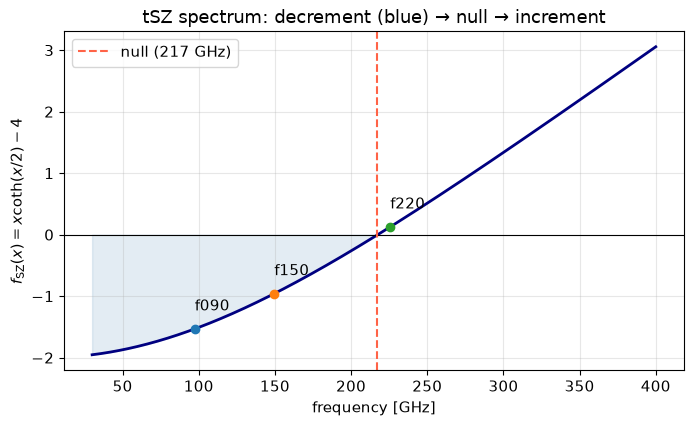

f_SZ( 97.4 GHz) = -1.532
f_SZ(149.6 GHz) = -0.958
f_SZ(225.7 GHz) = +0.127
-> 220 GHz sits almost on the null: it carries almost NO tSZ, so it is our dust tracer.


In [12]:
# --- the tSZ spectral function f(x) -------------------------------------------
def f_spectral(nu_Hz):
    '''Non-relativistic tSZ frequency function f(x) = x coth(x/2) - 4.'''
    x = (h_planck * np.asarray(nu_Hz)) / (k_B.value * T_cmb.to_value(u.K))
    return x / np.tanh(x / 2.0) - 4.0

nu = np.linspace(30e9, 400e9, 500)
fig, ax = plt.subplots(figsize=(8, 4.4))
fx = f_spectral(nu)
ax.plot(nu/1e9, fx, lw=2, color='navy')
ax.axhline(0, color='k', lw=.8); ax.axvline(217, color='tomato', ls='--', label='null (217 GHz)')
for name in ['f090','f150','f220']:
    g = ACT[name]['nu']; ax.plot(g, f_spectral(g*1e9), 'o'); ax.annotate(name, (g, f_spectral(g*1e9)+0.3))
ax.fill_between(nu/1e9, fx, 0, where=(fx<0), color='steelblue', alpha=.15)
ax.set_xlabel('frequency [GHz]'); ax.set_ylabel(r'$f_{\rm SZ}(x)=x\coth(x/2)-4$')
ax.set_title('tSZ spectrum: decrement (blue) → null → increment'); ax.legend()
plt.savefig('sza_fig_spectral.png', dpi=130, bbox_inches='tight'); plt.show()
for g in [97.4, 149.6, 225.7]:
    print(f'f_SZ({g:5.1f} GHz) = {f_spectral(g*1e9):+.3f}')
print('-> 220 GHz sits almost on the null: it carries almost NO tSZ, so it is our dust tracer.')

## 3. Compton-$y$ and the optical depth $\tau$

The amplitude of the distortion is the line-of-sight integral of the electron **pressure**:

$$\boxed{\;y=\dfrac{\sigma_T}{m_e c^2}\int n_e\,k_B T_e\,dl\;}\qquad\text{(Carlstrom+2002, Eq. for }y)$$

The closely related **optical depth** integrates the electron **density** alone:

$$\boxed{\;\tau=\sigma_T\int n_e\,dl\;}$$

**Symbols:** $\sigma_T$ — Thomson cross-section; $m_e c^2$ — electron rest energy; $n_e$ — electron number
density; $T_e$ — electron temperature; $dl$ — path length. So $y$ measures *thermal energy* ($n_eT_e$)
while $\tau$ measures *how many electrons* ($n_e$). Their ratio is a density-weighted temperature,
$y/\tau\sim k_BT_e/m_ec^2$ — this is why a $y$–$\tau$ relation exists (Section 16).

> 📦 **Order of magnitude — a BGS group.** Take $n_e\sim10^{-4}\,{\rm cm^{-3}}$, $k_BT_e\sim1\,$keV over a
> path $L\sim1\,$Mpc$=3\times10^{24}\,$cm. Then
> $y\sim\dfrac{\sigma_T}{m_ec^2}n_ek_BT_eL
>   \sim(6.65\times10^{-25})(1/511)\,(10^{-4})(1)\,(3\times10^{24})\approx4\times10^{-7}$,
> and $\tau\sim\sigma_T n_e L\sim(6.65\times10^{-25})(10^{-4})(3\times10^{24})\approx2\times10^{-4}$.
> Both tiny — which is why we must **stack thousands of galaxies**.

## 4. The measurement filter: compensated aperture photometry

We cannot resolve a single galaxy's gas halo, so we measure an **aperture-integrated** signal and
subtract a local background. The **disk-minus-ring** (or "compensated aperture photometry", CAP) filter
averages the map over a disk of radius $R$ and subtracts the average over a surrounding ring of equal area
(inner radius $R$, outer radius $\sqrt2\,R$):

$$\boxed{\;y_{\rm AP}(R)=\dfrac{1}{N_d}\sum_{i\in\text{disk}} y_i-\dfrac{1}{N_r}\sum_{j\in\text{ring}} y_j\;}
\qquad\text{(Schaan+2021; Vavagiakis+2021)}$$

and the stacked signal for a sample is the plain average over sources,

$$\boxed{\;\bar y_{\rm AP}=\dfrac{1}{N_{\rm src}}\sum_{k=1}^{N_{\rm src}} y_{{\rm AP},k}\;}$$

**Symbols:** $N_d,N_r$ — number of pixels in disk and ring; the equal-area ring ($\sqrt2R$ outer radius)
makes the filter **compensated**: a spatially flat background integrates to zero, killing the huge primary
CMB and atmospheric offsets. For BGS we use $R_{\rm AP}=2.7'$. The *radial profile* is $y_{\rm AP}(R)$ as
$R$ is varied.

🎓 *Concept — why subtract a ring?* The primary CMB has structure on degree scales — enormous compared to
our nano-Kelvin signal but almost **constant** across a 5′ aperture. Subtracting the ring removes any
smooth local level, leaving only signal that is *concentrated* like our galaxies' gas.

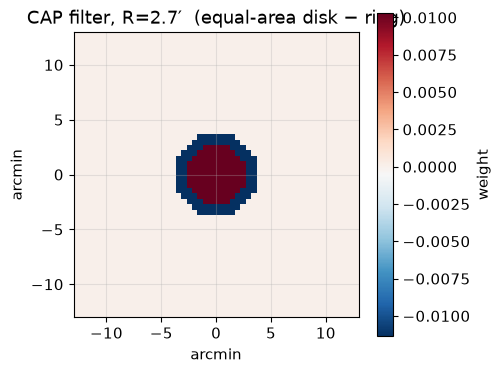

disk pixels=97, ring pixels=88 (equal area by construction); sum of weights = -2.8e-17 (compensated ~ 0)


In [13]:
# --- cutout geometry + illustrate the disk-minus-ring (CAP) filter -------------
# We cut a small square directly from the CAR map at each galaxy (fast). The ACT pixel
# is 0.5', which already resolves the ~1.6-2.1' beam, so no finer reprojection is needed.
PXA, H = 0.5, 26                                 # arcmin/pixel (ACT native), stamp half-size [pix]
npix, half = 2*H + 1, H*0.5                      # 53 px cutout, half-size 13 arcmin
                                                 # (big enough that the largest ring, sqrt(2)*7',
                                                 #  stays covered after the cos(dec) RA compression)
dyp, dxp = np.mgrid[-H:H+1, -H:H+1].astype(float)  # pixel offsets from the centre
r_arcmin = PXA*np.hypot(dyp, dxp)                # nominal cutout radius grid [arcmin]

R = CONFIG['APERTURE']
disk =  r_arcmin < R
ring = (r_arcmin >= R) & (r_arcmin < np.sqrt(2)*R)
kern = np.where(disk, 1.0/disk.sum(), 0.0) - np.where(ring, 1.0/ring.sum(), 0.0)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(kern, extent=[-half,half,-half,half], cmap='RdBu_r')
ax.set_title(f'CAP filter, R={R}′  (equal-area disk − ring)')
ax.set_xlabel('arcmin'); ax.set_ylabel('arcmin'); plt.colorbar(im, label='weight')
plt.savefig('sza_fig_capkernel.png', dpi=130, bbox_inches='tight'); plt.show()
print(f'disk pixels={disk.sum()}, ring pixels={ring.sum()} (equal area by construction); '
      f'sum of weights = {kern.sum():.1e} (compensated ~ 0)')

## 5. Error bars: the jackknife

We estimate the uncertainty on $\bar y_{\rm AP}$ by **delete-one jackknife** over $N$ subsamples:

$$\boxed{\;\sigma_{\rm jk}=\sqrt{\dfrac{N-1}{N}\sum_{i=1}^{N}\big(\bar y_{(i)}-\bar y\big)^2}\;}
\qquad\text{(standard jackknife; Schaan+2021)}$$

**Symbols:** $\bar y_{(i)}$ — stacked signal with subsample $i$ removed; $\bar y$ — mean of them. The
$(N-1)/N$ factor corrects for the strong correlation between delete-one estimates. This propagates map
noise **and** source-to-source scatter without assuming Gaussian pixels.

# Part 3 — Building the stacking pipeline

Now the code. Three ingredients: (1) cut a small image ("thumbnail") out of the CAR map at each galaxy,
(2) apply the CAP filter to get $y_{\rm AP}$, (3) average and jackknife. For memory safety we accumulate a
running **sum image** (for the stacked-submap figures) and keep only the per-source CAP scalars (for the
mean and the jackknife) — never all thumbnails at once.

In [14]:
# --- convert a map's native units to Compton-y at the aperture -----------------
def to_y_factor(name):
    '''Multiplicative factor turning this map's AP value into Compton-y.
       y-maps: 1. Single-freq (uK): 1/(f_SZ(nu)*T_cmb_uK). 220 GHz kept in uK (near the null).'''
    v = ACT[name]
    if v['unit'] == 'y':      return 1.0, 'y'
    if name == 'f220':        return 1.0, 'uK'            # essentially no tSZ; keep temperature
    return 1.0/(f_spectral(v['nu']*1e9)*T_cmb_uK), 'y'

RADII = np.arange(0.5, 7.01, 0.5)     # aperture radii for the radial profile [arcmin]

def _cap_cube(cube, R):
    '''disk-minus-ring on a stack of images (n,ny,nx) using the nominal radius grid.'''
    d =  r_arcmin < R
    g = (r_arcmin >= R) & (r_arcmin < np.sqrt(2)*R)
    return np.nanmean(cube[:, d], 1) - np.nanmean(cube[:, g], 1)

def stack_map(name, ra, dec, radii=RADII, chunk=3000, rotate=False):
    '''Stack `name` at (ra,dec) via direct native-pixel cutouts (vectorised, fast).
       Per-source CAP arrays stay aligned to the input order (invalid cutouts -> NaN), so
       mass-bin subsets can reuse one full-sample stack. Each cutout's RA axis is scaled by
       cos(dec) so the disk/ring radii are true angular separations.'''
    m = load_map(name)
    if m is None: return None
    marr = np.asarray(m); ny, nx = marr.shape
    fac, unit = to_y_factor(name)
    pix = m.sky2pix(np.deg2rad(np.stack([dec, ra], axis=0)))     # (2,N) [y,x] float pixels
    iy = np.round(pix[0]).astype(int); ix = np.round(pix[1]).astype(int)
    cosd = np.cos(np.deg2rad(dec))
    inrange = (iy >= H) & (iy < ny - H)                          # y must fit (x wraps safely)
    ssum = np.zeros((npix, npix)); cnt = np.zeros((npix, npix))
    cap_R  = np.full(len(ra), np.nan)
    cap_prof = np.full((len(ra), len(radii)), np.nan)
    allR = [CONFIG['APERTURE'], *radii]
    for i0 in range(0, len(ra), chunk):
        idx = np.arange(i0, min(i0+chunk, len(ra)))[inrange[i0:i0+chunk]]
        if not len(idx): continue
        yy = (iy[idx][:, None, None] + dyp[None]).astype(int)     # (c,npix,npix)
        xx = ((ix[idx][:, None, None] + dxp[None]).astype(int)) % nx
        cube = marr[yy, xx]                                       # native cutouts
        if rotate:                                                # null test: scramble orientation
            cube = np.stack([np.rot90(s, k) for s, k in zip(cube, np.random.randint(0, 4, len(idx)))])
        r = PXA*np.hypot(dyp[None], dxp[None]*cosd[idx][:, None, None])   # true radius [arcmin]
        fin = np.isfinite(cube)
        ssum += np.where(fin, cube, 0.0).sum(0); cnt += fin.sum(0)
        for j, R in enumerate(allR):
            d = (r < R) & fin; g = (r >= R) & (r < np.sqrt(2)*R) & fin
            val = ((cube*d).sum((1,2))/np.maximum(d.sum((1,2)), 1)
                 - (cube*g).sum((1,2))/np.maximum(g.sum((1,2)), 1)) * fac
            if j == 0: cap_R[idx] = val
            else:      cap_prof[idx, j-1] = val
    return dict(name=name, unit=unit, factor=fac, image=ssum/np.maximum(cnt, 1),
                cap=cap_R, prof=cap_prof, n=int(np.isfinite(cap_R).sum()))

print('pipeline ready:  RADII =', RADII[0], '..', RADII[-1], 'arcmin')

pipeline ready:  RADII = 0.5 .. 7.0 arcmin


In [15]:
# --- mean + jackknife error from per-source CAP arrays -------------------------
def jackknife(cap, N=None, labels=None):
    '''cap: (Nsrc,) or (Nsrc, nR). Returns (mean, sigma) via delete-one jackknife.

    labels=None  -> delete-one over N random permutation groups. Fast, but because the groups
                    are scattered across the sky each one sees the same large-scale modes, so
                    this estimates shot noise and little else.
    labels given -> delete-one over contiguous sky patches (one label per source). Each deletion
                    removes a whole region, so the scatter between deletions also picks up
                    sample variance. Expect the error bars to GROW relative to the permutation
                    version -- that is the estimator getting more honest, not a regression.
    '''
    N = N or CONFIG['N_JACKKNIFE']
    scalar = cap.ndim == 1
    cap = cap[:, None] if scalar else cap
    good = np.isfinite(cap).all(1)          # drop invalid cutouts, keep alignment elsewhere
    cap = cap[good]
    Nsrc = len(cap)
    if labels is None:
        N = max(min(N, Nsrc), 2)
        idx = np.random.permutation(Nsrc); groups = np.array_split(idx, N)
    else:
        labels = np.asarray(labels)[good]
        uniq = np.unique(labels); N = max(len(uniq), 2)
        groups = [np.flatnonzero(labels == u) for u in uniq]
    full = cap.mean(0)
    jk = np.array([np.delete(cap, g, axis=0).mean(0) for g in groups])
    sig = np.sqrt((N-1)/N * np.sum((jk - jk.mean(0))**2, axis=0))
    return (float(full[0]), float(sig[0])) if scalar else (full, sig)

def stacked_value(name, mask=None, sample=None, **kw):
    '''Convenience: stacked CAP at the nominal aperture with jackknife error, for a mask.'''
    sample = BGS if sample is None else sample
    ra, dec = sample['RA'], sample['DEC']
    if mask is not None: ra, dec = ra[mask], dec[mask]
    s = stack_map(name, ra, dec, **kw)
    if s is None: return None
    m, e = jackknife(s['cap'])
    return dict(mean=float(m), err=float(e), stack=s)

print('estimators ready.')

estimators ready.


# Part 4 — Results: stacking on the two samples

We now run the pipeline and reproduce, for both samples, the figures of a full tSZ analysis. Each
stack is computed **once** and cached; the mass-binned figures reuse the stored per-source CAP values
(bins are just subsets), so nothing is stacked twice.

Where a sample provides randoms, `profile()` and `y_ap()` quietly do two extra things for it: they
subtract the stacked signal at random positions, and they jackknife over sky patches instead of random
groups. So the LS10 curves below are **background-subtracted** and carry **sample-variance** errors,
while the BGS curves are raw with shot-noise-only errors. That is not an apples-to-apples comparison of
error bars — it is a demonstration of what a random catalogue buys you.

### 6.1 A cache with two samples in it — and a trap worth pausing on

Stacking is expensive, so we memoise: each `(sample, map)` stack is computed once and reused by
every figure that needs it. The maps themselves are memoised separately in `_MAPCACHE`, which is
why a second sample is affordable at all — the ~14 GB of ACT maps is loaded once and shared.

The trap is in the **cache key**. With one sample the obvious key is the map name, and it works.
Add a second sample and that same key silently returns the *first* sample's stack for every
`get_stack('ymap', sample=LS10)` call. Nothing raises. The figures render. The numbers are
plausible — they are, after all, a real measurement of a real sample — they are just not the
sample you asked for.

This is the characteristic failure mode of caching in scientific code: it does not crash, it
lies. The fix is to key on everything the cached value depends on, which here means
`(sample['key'], name)`. Whenever you memoise, ask what the result depends on, and check that
*all* of it is in the key.

In [16]:
# --- compute (and cache) the full-sample stack for a given map -----------------
STACKS = {}
def get_stack(name, sample=None):
    '''Stack of map `name` on `sample`'s galaxies. Cached on (sample, map) -- see section 6.1.'''
    sample = BGS if sample is None else sample
    k = (sample['key'], name)
    if k not in STACKS:
        STACKS[k] = stack_map(name, sample['RA'], sample['DEC'])
    return STACKS[k]

RAND_STACKS = {}
def get_rand_stack(name, sample):
    '''Stack of map `name` at the sample's RANDOM positions, or None if it ships no randoms.

    This is the mean signal the filter picks up from a position drawn from the survey geometry
    but with no galaxy at it: the footprint's own mean y, plus whatever the CAP filter leaves of
    the large-scale sky. Subtracting it is what makes the measurement an excess ABOVE the mean
    rather than an absolute y.'''
    if sample.get('rand_ra') is None: return None
    k = (sample['key'], name)
    if k not in RAND_STACKS:
        RAND_STACKS[k] = stack_map(name, sample['rand_ra'], sample['rand_dec'])
    return RAND_STACKS[k]

def _bgsub(mu, er, name, sample):
    '''Subtract the random-position background (and propagate its error) where available.'''
    rs = get_rand_stack(name, sample)
    if rs is None: return mu, er
    key = 'cap' if np.ndim(mu) == 0 else 'prof'
    mr, er_r = jackknife(rs[key], labels=sample.get('rand_jk'))
    return mu - mr, np.hypot(er, er_r)

def profile(stack, mask=None, sample=None):
    '''Mean radial profile + jackknife error, reusing the stored per-source CAP arrays.
       Uses the sample's sky-patch jackknife and random background when it has them.'''
    sample = BGS if sample is None else sample
    prof = stack['prof'] if mask is None else stack['prof'][mask]
    lab = sample['jk']
    if lab is not None and mask is not None: lab = lab[mask]
    mu, er = jackknife(prof, labels=lab)
    return _bgsub(mu, er, stack['name'], sample)

def y_ap(name, sample=None, mask=None):
    '''Stacked CAP Compton-y at the nominal aperture: (mean, error), background-subtracted.'''
    sample = BGS if sample is None else sample
    s = get_stack(name, sample)
    if s is None: return None, None
    cap = s['cap'] if mask is None else s['cap'][mask]
    lab = sample['jk']
    if lab is not None and mask is not None: lab = lab[mask]
    mu, er = jackknife(cap, labels=lab)
    return _bgsub(mu, er, name, sample)

def circle(ax, R, **kw):
    t = np.linspace(0, 2*np.pi, 100)
    ax.plot(R*np.cos(t), R*np.sin(t), **kw)

print('Stacking helpers ready. Computing the full-sample y-map stacks as a first test...')
for _s in (BGS, LS10):
    m, e = y_ap('ymap', _s)
    if m is not None:
        n = get_stack('ymap', _s)['n']
        print(f'  {_s["label"]:12s} y_AP(R={CONFIG["APERTURE"]} arcmin) = ({m:+.2e} ± {e:.1e})   '
              f'S/N = {m/e:5.1f}   (fiducial ILC, N={n:,})')

Stacking helpers ready. Computing the full-sample y-map stacks as a first test...


  DESI BGS     y_AP(R=2.7 arcmin) = (+1.59e-08 ± 8.2e-09)   S/N =   1.9   (fiducial ILC, N=29,988)


  LS10 M*>11.5 y_AP(R=2.7 arcmin) = (+2.40e-07 ± 1.7e-08)   S/N =  14.4   (fiducial ILC, N=29,878)


## 7. Stacked submaps (Figure 3)

The most direct view: the average 20′×20′ image around all BGS galaxies, in each map. The single-frequency
90/150 GHz stacks show a bright **central source** — dust and radio emission from the galaxies themselves —
on top of (or overwhelming) the tSZ decrement. The ILC $y$-maps isolate the tSZ, which appears as a
compact positive $y$ blob at the centre.

  [f090] loaded  shape=(10320, 43200)  (uK)


  [f150] loaded  shape=(10320, 43200)  (uK)


  [ymap_cib] loaded  shape=(10320, 43200)  (y)


  [ymap_dbeta] loaded  shape=(10320, 43200)  (y)


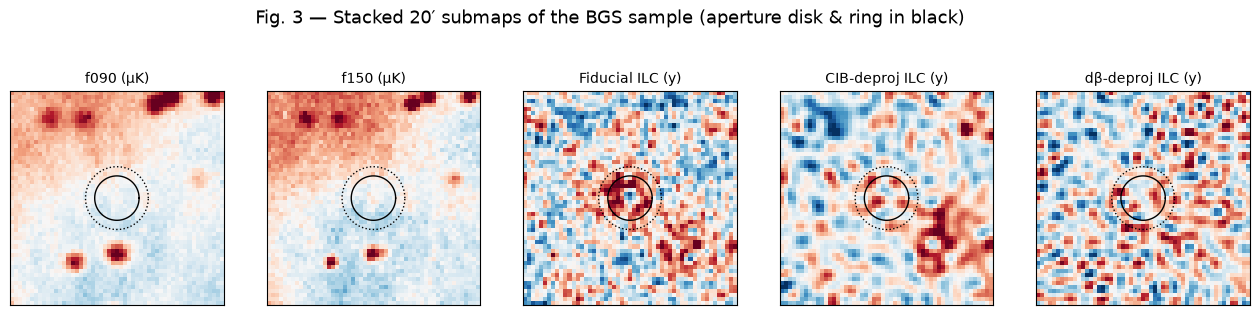

In [17]:
# --- Figure 3: stacked submaps of the BGS sample ------------------------------
panels = ['f090', 'f150', 'ymap', 'ymap_cib', 'ymap_dbeta']
titles = ['f090 (µK)', 'f150 (µK)', 'Fiducial ILC (y)', 'CIB-deproj ILC (y)', 'dβ-deproj ILC (y)']
fig, axes = plt.subplots(1, len(panels), figsize=(16, 3.4))
for ax, name, ttl in zip(axes, panels, titles):
    s = get_stack(name)
    ax.set_title(ttl, fontsize=10)
    if s is None:
        ax.text(.5, .5, 'map not\\ndownloaded', ha='center', va='center'); ax.axis('off'); continue
    img = s['image']
    v = np.nanpercentile(np.abs(img - np.nanmedian(img)), 99)
    ax.imshow(img, extent=[-half,half,-half,half], vmin=np.nanmedian(img)-v,
              vmax=np.nanmedian(img)+v, cmap='RdBu_r' if s['unit']=='y' else 'viridis')
    circle(ax, CONFIG['APERTURE'], color='k', lw=1)
    circle(ax, np.sqrt(2)*CONFIG['APERTURE'], color='k', lw=1, ls=':')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Fig. 3 — Stacked 20′ submaps of the BGS sample (aperture disk & ring in black)', y=1.05)
plt.savefig('sza_fig03_submaps.png', dpi=130, bbox_inches='tight'); plt.show()

## 8. Radial profiles at 90 and 150 GHz (Figure 4)

Instead of a single aperture, scan the CAP radius $R$ from 0.5′ to 7′. At small radii the 150 GHz profile
sits **below** 90 GHz: that is dust/CIB emission, which is brighter at 150 GHz, filling in the decrement.
The two frequencies have *different beams* (FWHM 2.1′ vs 1.4′); we quantify how much that alone shifts
an aperture measurement with a forward model in the next section.

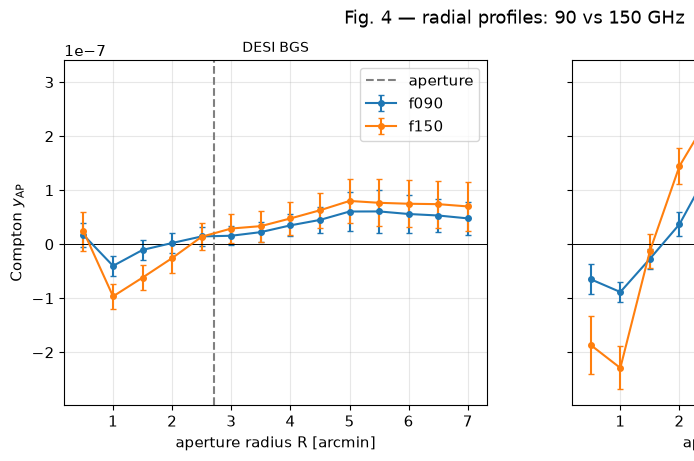

Note the 150 GHz suppression at small R relative to 90 GHz — the dust/CIB signature.
The LS10 panel has a background-subtracted, sky-patch jackknife: bigger error bars, but they mean what they say.


In [18]:
# --- Figure 4: 90 vs 150 GHz radial profiles (Compton-y) ----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
ok = False
for ax, s in zip(axes, [BGS, LS10]):
    for name, col in [('f090', 'C0'), ('f150', 'C1')]:
        st = get_stack(name, s)
        if st is None: continue
        ok = True
        mu, er = profile(st, sample=s)
        ax.errorbar(RADII, mu, er, color=col, marker='o', ms=4, capsize=2, label=name)
    ax.axhline(0, color='k', lw=.7)
    ax.axvline(CONFIG['APERTURE'], color='grey', ls='--', label='aperture')
    ax.set_xlabel('aperture radius R [arcmin]'); ax.set_title(s['label'], fontsize=10); ax.legend()
axes[0].set_ylabel('Compton $y_{\\rm AP}$')
fig.suptitle('Fig. 4 — radial profiles: 90 vs 150 GHz', y=0.99)
fig.subplots_adjust(top=0.88, bottom=0.13)
if ok: plt.savefig('sza_fig04_freq_profiles.png', dpi=130)
plt.show()
if ok:
    print('Note the 150 GHz suppression at small R relative to 90 GHz — the dust/CIB signature.')
    print('The LS10 panel has a background-subtracted, sky-patch jackknife: bigger error bars, '
          'but they mean what they say.')

### The beam-correction forward model

The maps have different beams, so at a fixed aperture they collect different fractions of the same signal.
We model this once with the gas **pressure profile** of Battaglia et al. (2012), project it to a
Compton-$y$ profile, convolve with each map's beam, and take the ratio of aperture values. This is the
same forward model as N10b — reused here at the **BGS** mean halo mass and redshift.

> 🔧 **Reusable version.** The `beam_smear` and `ap_of` helpers below are written here from scratch so the mechanism is visible. The production versions live in `hod_mod.observables.cap_filter` (compensated aperture photometry) and `HaloModelCrossSpectra.projected_gy(..., beam_fwhm_arcmin=)` (the beam) — in fact this notebook's `ap_of` is the reference implementation `cap_filter` was written against, so the two agree by construction (integrated $T_{\rm AP}=2Y(\theta_d)-Y(\sqrt2\,\theta_d)$, ring at $\sqrt2\,\theta_d$).

In [19]:
# --- Battaglia-2012 gNFW pressure -> y(theta) -> beam -> AP correction factors --
Msol_cgs = (1*u.Msun).to_value(u.g); G_cgs = const.G.to_value('cm3 g-1 s-2')
rho_c0 = 1.87847e-29 * 0.7**2; Om_b, Ob_b = 0.25, 0.044; fb = Ob_b/Om_b
f_e = (2 + 2*0.76)/(3 + 5*0.76)                      # electrons per gas particle (X_H=0.76)
def Pth_battaglia(r_Mpc, M, z):
    Ez2 = Om_b*(1+z)**3 + (1-Om_b)
    r200 = (3*M*Msol_cgs/(4*np.pi*200.*rho_c0*Ez2))**(1/3)
    rvir = r200/(1*u.Mpc).to_value(u.cm)
    P200 = G_cgs*(M*Msol_cgs)*200.*(rho_c0*Ez2)*fb/(2*r200)
    P0 = 18.1*(M/1e14)**0.154*(1+z)**(-0.758)
    bt = 4.35*(M/1e14)**0.0393*(1+z)**0.415
    xc = 0.497*(M/1e14)**(-0.00865)*(1+z)**0.731
    x = r_Mpc/rvir
    return P0*(x/xc)**(-0.3)*(1+(x/xc))**(-bt)*P200     # erg cm^-3

sigT_cgs = sigma_T.to_value('cm2'); mec2_erg = (m_e*c**2).to_value('erg'); Mpc_cm = (1*u.Mpc).to_value(u.cm)
th = np.radians(np.linspace(0.02, 12, 200)/60)

def y_theta_of(M, z):
    '''Beam-free y(theta) for a Battaglia halo of mass M200c at redshift z.'''
    DA = cosmo.angular_diameter_distance(z).to_value(u.Mpc)
    def y1(th_rad):
        b = th_rad*DA
        val = quad(lambda l: float(Pth_battaglia(np.sqrt(b*b+l*l), M, z)), 0, 10., limit=100)[0]
        return sigT_cgs/mec2_erg * f_e * 2*val*Mpc_cm
    return np.array([y1(t) for t in th])

def beam_smear(prof, th, fwhm_arcmin):
    sig = np.radians(fwhm_arcmin/60)/2.355
    phi = np.linspace(0, 2*np.pi, 41); out = np.empty_like(th)
    B = lambda d: np.exp(-d**2/(2*sig**2))/(2*np.pi*sig**2)
    for i, t in enumerate(th):
        d = np.sqrt(np.clip(t*t+th*th-2*t*th*np.cos(phi[:,None]), 0, None))
        out[i] = np.trapezoid(th*prof*np.trapezoid(B(d), phi, axis=0), th)
    return out
def ap_of(prof, th, R):
    Ycum = 2*np.pi*cumulative_trapezoid(th*prof, th, initial=0)
    f = interp1d(th, Ycum, bounds_error=False, fill_value=(0., Ycum[-1]))
    Rr = np.radians(R/60)
    return (2*f(Rr) - f(np.sqrt(2)*Rr))
R0 = CONFIG['APERTURE']

# Effective halo per sample. The beam correction depends on how big the halo looks on the sky,
# so it is NOT a property of the map alone — a more massive, more distant sample needs its own.
#   BGS : <logM*> ~ 10.7  ->  M200c ~ 1e13 Msun
#   LS10: logM* > 11.5    ->  M200c ~ 1e14 Msun (a group/small-cluster scale halo)
HALO = {'bgs' : (1e13, float(np.clip(BGS['Z'].mean(),  0.05, 0.5)), BGS['label']),
        'ls10': (1e14, float(np.clip(LS10['Z'].mean(), 0.05, 0.5)), LS10['label'])}
M_bgs, z_bgs = HALO['bgs'][0], HALO['bgs'][1]      # kept for the discussion below
BEAMCORR = {}
print(f'Beam-correction factors at R={R0:.1f} arcmin (relative to f150):\n')
print(f'  {"sample":14s} {"M200c":>8s} {"<z>":>6s} | ' + ' '.join(f'{n:>7s}' for n in ['f090','f150','f220','ilc']))
for key, (M, z, lab) in HALO.items():
    yt_k = y_theta_of(M, z)
    ap = {n: ap_of(beam_smear(yt_k, th, ACT[n]['fwhm']), th, R0) for n in ['f090','f150','f220']}
    ap['ilc'] = ap_of(beam_smear(yt_k, th, 1.6), th, R0)
    BEAMCORR[key] = {n: ap['f150']/ap[n] for n in ['f090','f150','f220','ilc']}
    print(f'  {lab:14s} {M:8.0e} {z:6.3f} | '
          + ' '.join(f'x{BEAMCORR[key][n]:6.3f}' for n in ['f090','f150','f220','ilc']))
yt = y_theta_of(*HALO['bgs'][:2])                  # the BGS profile, for reference below
print('\nThe corrections differ between the samples: the LS10 halo is ~10x more massive, so its '
      'pressure profile is broader on the sky and less of it is lost to the beam.')

Beam-correction factors at R=2.7 arcmin (relative to f150):

  sample            M200c    <z> |    f090    f150    f220     ilc


  DESI BGS          1e+13  0.243 | x 1.102 x 1.000 x 0.972 x 1.020


  LS10 M*>11.5      1e+14  0.262 | x 1.121 x 1.000 x 0.963 x 1.026

The corrections differ between the samples: the LS10 halo is ~10x more massive, so its pressure profile is broader on the sky and less of it is lost to the beam.


## 9. Radial profiles from the ILC $y$-maps (Figure 5)

The three ILC maps (fiducial, CIB-deprojected, d$\beta$-deprojected) should agree if foregrounds are under
control. Where they diverge — typically at small radii for the fiducial map (dust bias) and at large radii
for the deprojected maps (extra noise) — we learn how much foregrounds matter.

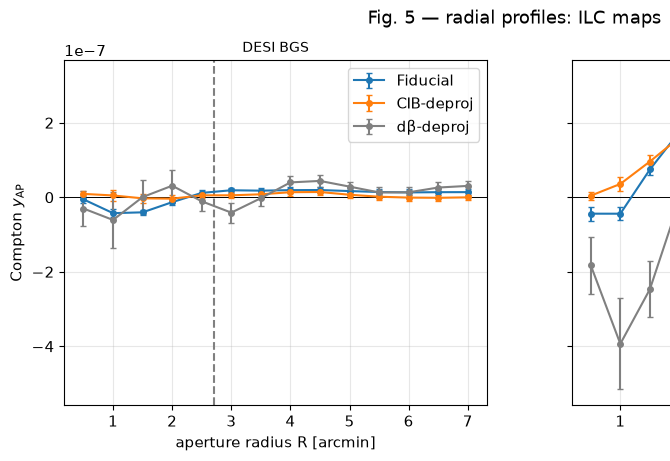

In [20]:
# --- Figure 5: ILC deprojection radial profiles ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True); ok = False
for ax, s in zip(axes, [BGS, LS10]):
    for name, col, lab in [('ymap','C0','Fiducial'), ('ymap_cib','C1','CIB-deproj'),
                           ('ymap_dbeta','0.5','dβ-deproj')]:
        st = get_stack(name, s)
        if st is None: continue
        ok = True; mu, er = profile(st, sample=s)
        ax.errorbar(RADII, mu, er, color=col, marker='o', ms=4, capsize=2, label=lab)
    ax.axhline(0, color='k', lw=.7); ax.axvline(R0, color='grey', ls='--')
    ax.set_xlabel('aperture radius R [arcmin]'); ax.set_title(s['label'], fontsize=10); ax.legend()
axes[0].set_ylabel('Compton $y_{\\rm AP}$')
fig.suptitle('Fig. 5 — radial profiles: ILC maps', y=0.99)
fig.subplots_adjust(top=0.88, bottom=0.13)
if ok: plt.savefig('sza_fig05_ilc_profiles.png', dpi=130)
plt.show()

## 10. A large-scale CIB test: the ring-ring filter (Figure 6)

The disk-minus-ring filter is sensitive to signal *inside* the aperture. To probe **large-scale** CIB
contamination we instead difference two adjacent **equal-area rings** (inner $R_0<R<R_1$, outer
$R_1<R<\sqrt{2R_1^2-R_0^2}$) and scan $R_1$ (Liu et al. 2025). If 90 and 150 GHz agree here, there is
little large-scale CIB.

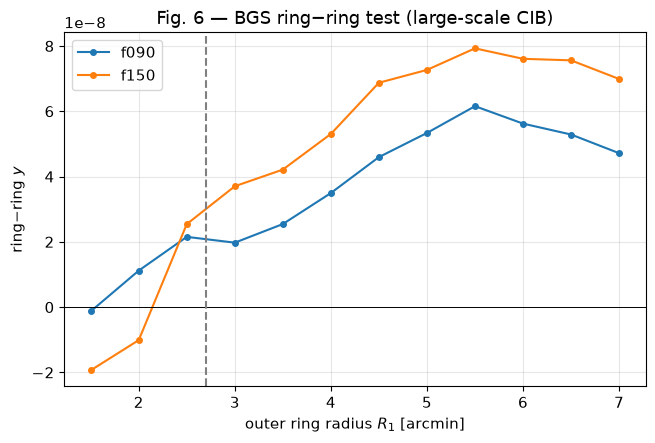

90 and 150 GHz agree beyond the aperture -> little large-scale CIB (as in the LRG analysis).


In [21]:
# --- Figure 6: ring-ring profiles at 90 and 150 GHz --------------------------
def ringring_cube(cube, R0i, R1, fac):
    inner = (r_arcmin>=R0i)&(r_arcmin<R1)
    R2 = np.sqrt(2*R1**2 - R0i**2)
    outer = (r_arcmin>=R1)&(r_arcmin<R2)
    return (np.nanmean(cube[:,inner],1) - np.nanmean(cube[:,outer],1))*fac

R1s = np.arange(1.5, 7.01, 0.5); R0i = 1.0
fig, ax = plt.subplots(figsize=(7.5,4.6)); ok=False
for name,col in [('f090','C0'),('f150','C1')]:
    s = get_stack(name)
    if s is None: continue
    ok=True
    # ring-ring is a linear filter, so the sample mean equals the filter of the stacked image
    img = s['image'][None]
    rr = np.array([ringring_cube(img, R0i, R1, s['factor'])[0] for R1 in R1s])
    ax.plot(R1s, rr, color=col, marker='o', ms=4, label=name)
ax.axhline(0,color='k',lw=.7); ax.axvline(R0,color='grey',ls='--')
ax.set_xlabel('outer ring radius $R_1$ [arcmin]'); ax.set_ylabel('ring−ring $y$')
ax.set_title('Fig. 6 — BGS ring−ring test (large-scale CIB)'); ax.legend()
if ok: plt.savefig('sza_fig06_ringring.png', dpi=130, bbox_inches='tight')
plt.show()
if ok: print('90 and 150 GHz agree beyond the aperture -> little large-scale CIB (as in the LRG analysis).')

## 11. Where the dust lives: the 220 GHz map (Figure 7)

At 220 GHz the tSZ is essentially zero (Section 2), so a signal there is almost pure dust/CIB. A bright
central 220 GHz source confirms that the contamination seen at 150 GHz is dust from the galaxies.

  [f220] loaded  shape=(10320, 43200)  (uK)


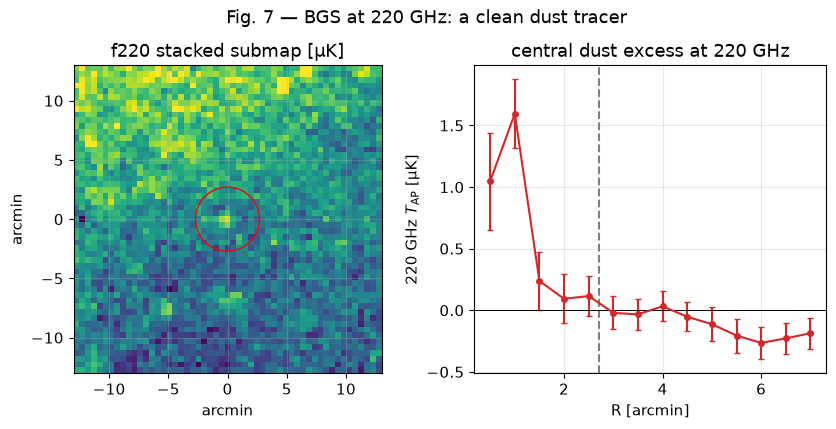

In [22]:
# --- Figure 7: 220 GHz stacked submap + radial profile -----------------------
s = get_stack('f220')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if s is None:
    for a in axes: a.text(.5,.5,'f220 not downloaded', ha='center'); a.axis('off')
else:
    img = s['image']
    v = np.nanpercentile(np.abs(img-np.nanmedian(img)), 99)
    axes[0].imshow(img, extent=[-half,half,-half,half], cmap='viridis',
                   vmin=np.nanmedian(img)-v, vmax=np.nanmedian(img)+v)
    circle(axes[0], R0, color='r', lw=1); axes[0].set_title('f220 stacked submap [µK]')
    axes[0].set_xlabel('arcmin'); axes[0].set_ylabel('arcmin')
    mu, er = profile(s)
    axes[1].errorbar(RADII, mu, er, color='C3', marker='o', ms=4, capsize=2)
    axes[1].axvline(R0, color='grey', ls='--'); axes[1].axhline(0, color='k', lw=.7)
    axes[1].set_xlabel('R [arcmin]'); axes[1].set_ylabel('220 GHz $T_{\\rm AP}$ [µK]')
    axes[1].set_title('central dust excess at 220 GHz')
fig.suptitle('Fig. 7 — BGS at 220 GHz: a clean dust tracer', y=1.02)
plt.savefig('sza_fig07_f220.png', dpi=130, bbox_inches='tight'); plt.show()

## 12. Removing dust with the 220 GHz map (Figure 8)

Because 220 GHz is (nearly) tSZ-free, we can scale it by the dust spectrum and subtract it from 90 and
150 GHz (Liu et al. 2025):

$$\boxed{\;y_{\rm deproj}(\nu)=y_{\rm raw}(\nu)-\dfrac{f(\nu)}{f(220)}\,y_{\rm raw}(220)\;}$$

where $f(\nu)$ is the modified-blackbody dust colour. We pick the dust spectral index $\beta$ that best
aligns the corrected 90 and 150 GHz profiles below the aperture. **Symbols:** $y_{\rm raw}$ — measured
profile; $f(\nu)\propto \nu^{3+\beta}/(e^{h\nu/k_BT_{\rm CIB}}-1)\cdot(dB/dT)^{-1}$; $T_{\rm CIB}\!=\!10.7$ K.

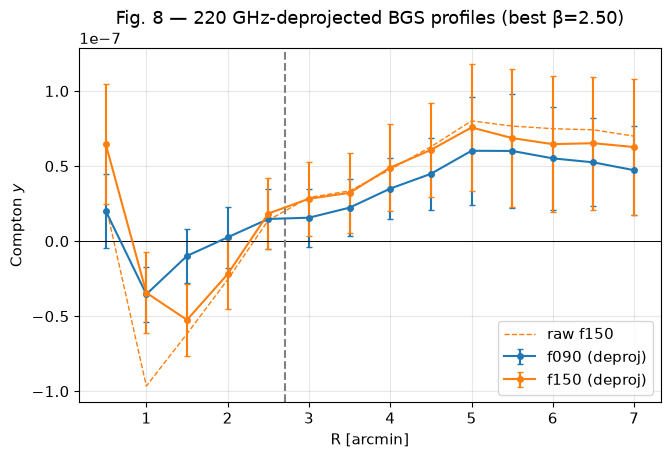

In [23]:
# --- Figure 8: 220 GHz deprojection of the 90 & 150 GHz profiles -------------
def dust_f(nu_GHz, beta=1.2, Tcib=10.7):
    x = h_planck*nu_GHz*1e9/(k_B.value*Tcib)
    xc = h_planck*nu_GHz*1e9/(k_B.value*T_cmb.to_value(u.K))
    dBdT = xc**2*np.exp(xc)/(np.exp(xc)-1)**2                 # ~ dB/dT (up to consts)
    return (nu_GHz*1e9)**(3+beta)/(np.exp(x)-1)/dBdT

s90, s150, s220 = get_stack('f090'), get_stack('f150'), get_stack('f220')
fig, ax = plt.subplots(figsize=(7.5,4.6))
if None in (s90, s150, s220):
    ax.text(.5,.5,'need f090+f150+f220', ha='center', transform=ax.transAxes); ax.axis('off')
else:
    p90,_ = profile(s90); p150,_ = profile(s150)
    # raw 220 profile in y-units of the target frequency uses the same map (uK); convert per target nu
    p220_uK,_ = profile(s220)
    inner = RADII < R0
    def corrected(beta):
        c90 = p90 - dust_f(97.4,beta)/dust_f(225.7,beta)*p220_uK/(f_spectral(97.4e9)*T_cmb_uK)
        c150= p150- dust_f(149.6,beta)/dust_f(225.7,beta)*p220_uK/(f_spectral(149.6e9)*T_cmb_uK)
        return c90, c150
    betas = np.linspace(0.5, 2.5, 21)
    chi = [np.sum((corrected(b)[0][inner]-corrected(b)[1][inner])**2) for b in betas]
    beta_best = betas[int(np.argmin(chi))]
    c90, c150 = corrected(beta_best)
    ax.plot(RADII, p150, 'C1--', lw=1, label='raw f150')
    ax.errorbar(RADII, c90, profile(s90)[1], color='C0', marker='o', ms=4, capsize=2, label='f090 (deproj)')
    ax.errorbar(RADII, c150, profile(s150)[1], color='C1', marker='o', ms=4, capsize=2, label='f150 (deproj)')
    ax.axhline(0,color='k',lw=.7); ax.axvline(R0,color='grey',ls='--')
    ax.set_xlabel('R [arcmin]'); ax.set_ylabel('Compton $y$'); ax.legend()
    ax.set_title(f'Fig. 8 — 220 GHz-deprojected BGS profiles (best β={beta_best:.2f})')
    plt.savefig('sza_fig08_deproj.png', dpi=130, bbox_inches='tight')
plt.show()

## 13. Radio contamination (Figures 9 & 10)

Radio galaxies add positive flux at 90/150 GHz, biasing $y$ low. We flag every BGS target that has an
**NVSS** source within the aperture, define a **radio-clean** subsample by removing them, and compare the
stacks. Removing radio sources should *raise* the measured tSZ signal.

In [24]:
# --- flag radio-contaminated targets (NVSS within the aperture) --------------
# NVSS stops at Dec = -40. South of it we have no radio information at all, so a galaxy there is
# not "clean" -- it is UNKNOWN. Calling it clean would quietly let the very sources we are trying
# to remove back into the radio-clean stack, and the stack would look fine.
def flag_radio(sample):
    ra, dec = sample['RA'], sample['DEC']
    covered = dec > NVSS_DEC_MIN
    if nvss_ra is None or not len(nvss_ra):
        sample['radio'] = np.zeros(len(ra), bool)
        sample['nvss_covered'] = covered
        sample['clean'] = covered
        sample['nvss_ok'] = False
        return sample
    from astropy.coordinates import SkyCoord
    import astropy.units as uu
    cg = SkyCoord(ra*uu.deg, dec*uu.deg)
    cn = SkyCoord(nvss_ra*uu.deg, nvss_dec*uu.deg)
    _, sep, _ = cg.match_to_catalog_sky(cn)
    sample['radio'] = (sep.arcmin < R0) & covered
    sample['nvss_covered'] = covered
    sample['clean'] = (~sample['radio']) & covered
    sample['nvss_ok'] = True
    return sample

for _s in (BGS, LS10):
    flag_radio(_s)
    n = len(_s['RA']); nc = int(_s['nvss_covered'].sum()); nr = int(_s['radio'].sum())
    print(f'{_s["label"]:12s}: {nc:6,d}/{n:,} inside NVSS coverage (Dec > {NVSS_DEC_MIN:g}); '
          f'radio-contaminated within {R0}′: {nr:,} ({100*nr/max(nc,1):.1f}% of covered); '
          f'radio-clean: {int(_s["clean"].sum()):,}')
if not BGS['nvss_ok']:
    print('NVSS unavailable — showing full sample only for the radio figures.')

# the BGS masks keep their old names, so the figures below read as before
radio, clean = BGS['radio'], BGS['clean']

DESI BGS    : 30,000/30,000 inside NVSS coverage (Dec > -40); radio-contaminated within 2.7′: 9,092 (30.3% of covered); radio-clean: 20,908


LS10 M*>11.5: 24,541/30,000 inside NVSS coverage (Dec > -40); radio-contaminated within 2.7′: 10,423 (42.5% of covered); radio-clean: 14,118


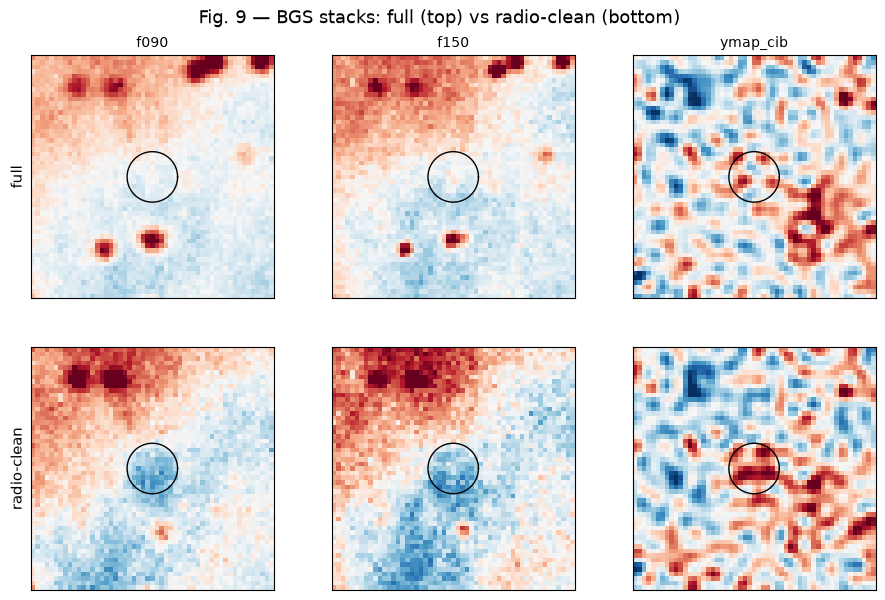

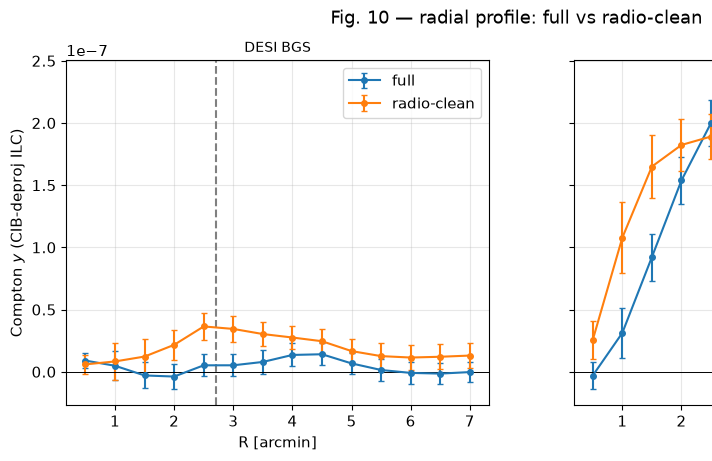

LS10: 5,459 galaxies lie south of Dec -40 and are excluded from BOTH LS10 curves — we cannot know whether they host a radio source.


In [25]:
# --- Figures 9 & 10: full vs radio-clean submaps and profiles ---------------
fig, axes = plt.subplots(2, 3, figsize=(11, 6.6))
for j, name in enumerate(['f090','f150','ymap_cib']):
    s = get_stack(name)
    for i, (mask, lab) in enumerate([(None,'full'), (clean,'radio-clean')]):
        ax = axes[i, j]
        if s is None: ax.text(.5,.5,'—',ha='center'); ax.axis('off'); continue
        # the stacked image is not stored per-source, so for the clean subset we re-stack
        # (cheap: the map is already in memory)
        img = s['image'] if mask is None else stack_map(name, BGS['RA'][mask], BGS['DEC'][mask])['image']
        v = np.nanpercentile(np.abs(img-np.nanmedian(img)),99)
        ax.imshow(img, extent=[-half,half,-half,half], cmap='RdBu_r' if s['unit']=='y' else 'viridis',
                  vmin=np.nanmedian(img)-v, vmax=np.nanmedian(img)+v)
        circle(ax, R0, color='k', lw=1); ax.set_xticks([]); ax.set_yticks([])
        if i==0: ax.set_title(name, fontsize=10)
        if j==0: ax.set_ylabel(lab)
fig.suptitle('Fig. 9 — BGS stacks: full (top) vs radio-clean (bottom)', y=0.99)
fig.subplots_adjust(top=0.92)
plt.savefig('sza_fig09_radio_submaps.png', dpi=130); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, s in zip(axes, [BGS, LS10]):
    st = get_stack('ymap_cib', s)
    if st is None: continue
    # For LS10 the "full" curve is restricted to NVSS-covered sky too, so that the only
    # difference between the two curves is the radio cut itself and not the footprint.
    base = None if s['key'] == 'bgs' else s['nvss_covered']
    for mask, lab, col in [(base, 'full', 'C0'), (s['clean'], 'radio-clean', 'C1')]:
        mu, er = profile(st, mask, sample=s)
        ax.errorbar(RADII, mu, er, color=col, marker='o', ms=4, capsize=2, label=lab)
    ax.axhline(0,color='k',lw=.7); ax.axvline(R0,color='grey',ls='--')
    ax.set_xlabel('R [arcmin]'); ax.legend(); ax.set_title(s['label'], fontsize=10)
axes[0].set_ylabel('Compton $y$ (CIB-deproj ILC)')
fig.suptitle('Fig. 10 — radial profile: full vs radio-clean', y=0.99)
fig.subplots_adjust(top=0.88, bottom=0.13)
plt.savefig('sza_fig10_radio_profiles.png', dpi=130)
plt.show()
print(f'LS10: {int((~LS10["nvss_covered"]).sum()):,} galaxies lie south of Dec {NVSS_DEC_MIN:g} and '
      f'are excluded from BOTH LS10 curves — we cannot know whether they host a radio source.')

## 14. The measurement: Compton-$y$ vs stellar mass (Figure 12)

Finally, the aperture value $\bar y_{\rm AP}$ for each of the six cumulative mass bins, from each map. The
signal grows with stellar mass — more massive galaxies live in more massive, hotter, gas-richer haloes.

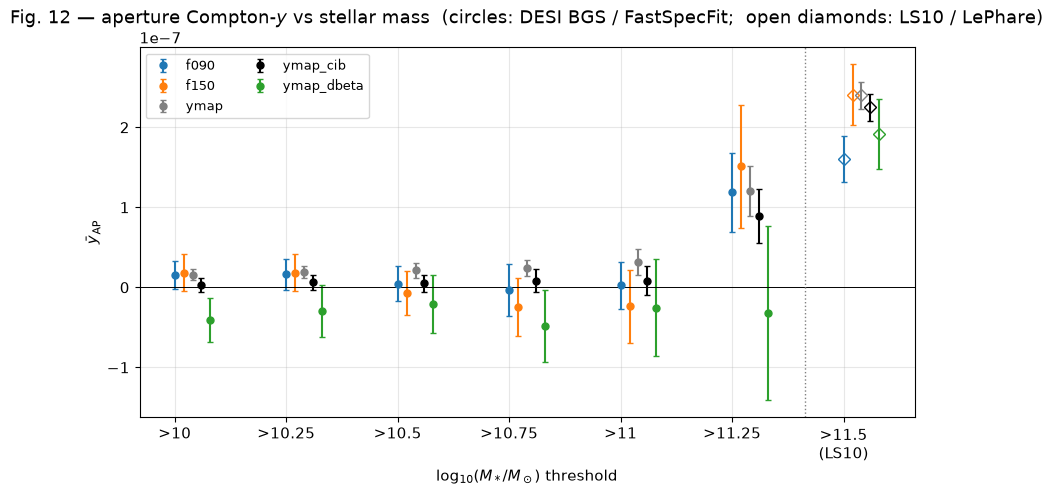

y grows with stellar mass: more massive galaxies live in more massive haloes with more hot gas. The LS10 point extends the trend ~0.25 dex past where DESI BGS runs out of galaxies — but remember its mass axis is LePhare, not FastSpecFit, so read its horizontal position as approximate.


In [26]:
# --- Figure 12: y_AP per mass bin, per map -----------------------------------
maps_for_y = [('f090','C0'), ('f150','C1'), ('ymap','0.5'), ('ymap_cib','k'), ('ymap_dbeta','C2')]
fig, ax = plt.subplots(figsize=(10,4.8)); x = np.arange(len(MASS_CUTS)); off=0
RESULT, RESULT_LS10 = {}, {}
for name, col in maps_for_y:
    s = get_stack(name)
    if s is None: continue
    ys, es = [], []
    for mc in MASS_CUTS:
        mask = BGS['LOGMSTAR'] > mc
        mn, er = y_ap(name, BGS, mask); ys.append(mn); es.append(er)
    RESULT[name] = (np.array(ys), np.array(es))
    ax.errorbar(x+off, ys, es, marker='o', ms=5, ls='none', capsize=2, color=col, label=name)
    # the LS10 sample is a single volume-limited bin: one point, open marker to mark that it
    # comes from a different catalogue with a different stellar-mass estimator
    m, e = y_ap(name, LS10)
    if m is not None:
        RESULT_LS10[name] = (m, e)
        ax.errorbar(len(MASS_CUTS)+off, m, e, marker='D', ms=6, ls='none', capsize=2,
                    color=col, mfc='none')
    off += 0.08
ax.axhline(0,color='k',lw=.7)
ax.axvline(len(MASS_CUTS)-0.35, color='grey', lw=1, ls=':')
ax.set_xticks(np.arange(len(MASS_CUTS)+1))
ax.set_xticklabels([f'>{mc:g}' for mc in MASS_CUTS] + [f'>{LS10_MASS_CUT:g}\n(LS10)'])
ax.set_xlabel('log$_{10}(M_*/M_\\odot)$ threshold')
ax.set_ylabel('$\\bar y_{\\rm AP}$')
ax.set_title('Fig. 12 — aperture Compton-$y$ vs stellar mass  '
             '(circles: DESI BGS / FastSpecFit;  open diamonds: LS10 / LePhare)')
ax.legend(fontsize=9, ncol=2)
plt.savefig('sza_fig12_ybin.png', dpi=130, bbox_inches='tight'); plt.show()
print('y grows with stellar mass: more massive galaxies live in more massive haloes with more hot '
      'gas. The LS10 point extends the trend ~0.25 dex past where DESI BGS runs out of galaxies — '
      'but remember its mass axis is LePhare, not FastSpecFit, so read its horizontal position '
      'as approximate.')

## 15. From $y$ to optical depth: the $\bar y$–$\bar\tau$ relation (Figures 14 & 17)

$y$ measures thermal energy; the **kinematic** SZ effect measures the optical depth $\tau$ directly. Because
$y/\tau\sim k_BT_e/m_ec^2$, simulations predict a tight power law (Battaglia 2016):

$$\boxed{\;\ln\bar\tau=\ln\tau_0+m\,\ln\!\Big(\dfrac{\bar y}{\bar y_0}\Big)\;,\quad \bar y_0=10^{-7}\;}$$

For BGS, the coefficients are calibrated on the **SIMBA** simulation (Davé et al. 2019):
$\ln\tau_0=-9.67\pm0.06$, $m=0.93\pm0.04$. We apply this relation to *our* measured $\bar y$ and compare
to the independent **pairwise-kSZ** optical depths of Hadzhiyska et al. (2026) for the same BGS bins.

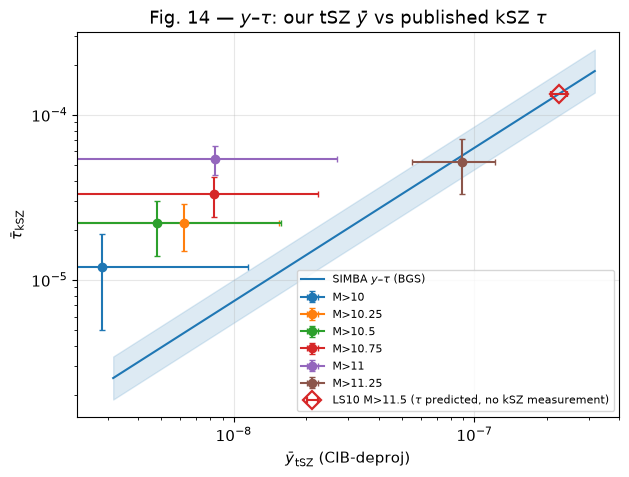

The filled BGS points test the relation: each has an INDEPENDENT kSZ tau on the y-axis.
The open LS10 diamond does not — it sits on the curve by construction, because the curve is where we read its tau off. It shows where a future kSZ measurement would have to land if the SIMBA relation holds this far up in mass.


In [27]:
# --- published calibration & comparison values (with citations) --------------
# SIMBA-calibrated y-tau relation for BGS (Battaglia 2016 form; params from the DESIxACT BGS analysis)
LN_TAU0, M_SLOPE, Y0 = -9.67, 0.93, 1e-7
def y_to_tau(ybar):  return np.exp(LN_TAU0) * (np.clip(ybar,1e-12,None)/Y0)**M_SLOPE

# pairwise-kSZ optical depths for BGS bins (Hadzhiyska et al. 2026, PRD 113 063565), x1e-5
TAU_KSZ = {'M>10':(1.2,0.7),'M>10.25':(2.2,0.7),'M>10.5':(2.2,0.8),
           'M>10.75':(3.3,0.9),'M>11':(5.4,1.1),'M>11.25':(5.2,1.9)}
# NOTE: there is no M>11.5 entry -- no published kSZ tau exists for the LS10 mass range, and we
# do not invent one. The LS10 point below is plotted where the SIMBA relation PREDICTS it sits.

# Figure 14: tau_kSZ vs y_tSZ with the SIMBA relation
fig, ax = plt.subplots(figsize=(7,5))
yy = np.logspace(-8.5, -6.5, 50)
ax.plot(yy, y_to_tau(yy), 'C0-', label='SIMBA $y$–$\\tau$ (BGS)')
ax.fill_between(yy, y_to_tau(yy)*np.exp(-0.3), y_to_tau(yy)*np.exp(0.3), color='C0', alpha=.15)
if 'ymap_cib' in RESULT:
    ys, es = RESULT['ymap_cib']
    for mc, ym, ye in zip(MASS_CUTS, ys, es):
        key = f'M>{mc:g}'; tk, tke = TAU_KSZ[key]
        if ym > 0:
            ax.errorbar(ym, tk*1e-5, yerr=tke*1e-5, xerr=ye, marker='o', capsize=2, label=key)
if 'ymap_cib' in RESULT_LS10:
    ym, ye = RESULT_LS10['ymap_cib']
    if ym > 0:
        ax.errorbar(ym, y_to_tau(ym), xerr=ye, marker='D', ms=9, mfc='none', mew=1.6,
                    color='C3', capsize=2, ls='none',
                    label='LS10 M>11.5 ($\\tau$ predicted, no kSZ measurement)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$\\bar y_{\\rm tSZ}$ (CIB-deproj)'); ax.set_ylabel('$\\bar\\tau_{\\rm kSZ}$')
ax.set_title('Fig. 14 — $y$–$\\tau$: our tSZ $\\bar y$ vs published kSZ $\\tau$'); ax.legend(fontsize=8)
plt.savefig('sza_fig14_ytau.png', dpi=130, bbox_inches='tight'); plt.show()
print('The filled BGS points test the relation: each has an INDEPENDENT kSZ tau on the y-axis.')
print('The open LS10 diamond does not — it sits on the curve by construction, because the curve '
      'is where we read its tau off. It shows where a future kSZ measurement would have to land '
      'if the SIMBA relation holds this far up in mass.')

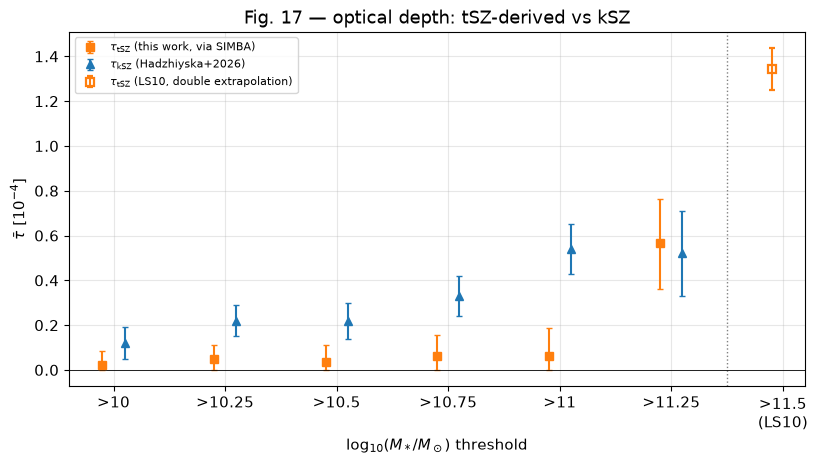

In [28]:
# --- Figure 17: optical-depth comparison per bin -----------------------------
fig, ax = plt.subplots(figsize=(9.5,4.6)); x = np.arange(len(MASS_CUTS))
if 'ymap_cib' in RESULT:
    ys, es = RESULT['ymap_cib']
    tau_tsz = y_to_tau(ys)
    tau_tsz_hi = y_to_tau(ys+es); tau_tsz_lo = y_to_tau(np.clip(ys-es,1e-12,None))
    ax.errorbar(x-0.1, tau_tsz/1e-4, yerr=[(tau_tsz-tau_tsz_lo)/1e-4,(tau_tsz_hi-tau_tsz)/1e-4],
                marker='s', ls='none', capsize=2, color='C1', label='$\\tau_{\\rm tSZ}$ (this work, via SIMBA)')
tks = np.array([TAU_KSZ[f'M>{mc:g}'][0] for mc in MASS_CUTS])
tke = np.array([TAU_KSZ[f'M>{mc:g}'][1] for mc in MASS_CUTS])
ax.errorbar(x+0.1, tks*1e-5/1e-4, yerr=tke*1e-5/1e-4, marker='^', ls='none', capsize=2,
            color='C0', label='$\\tau_{\\rm kSZ}$ (Hadzhiyska+2026)')
# LS10: tSZ-derived tau only. No kSZ triangle -- no published value exists at this mass.
if 'ymap_cib' in RESULT_LS10:
    ym, ye = RESULT_LS10['ymap_cib']
    t = y_to_tau(ym); thi = y_to_tau(ym+ye); tlo = y_to_tau(max(ym-ye, 1e-12))
    ax.errorbar([len(MASS_CUTS)-0.1], [t/1e-4], yerr=[[(t-tlo)/1e-4],[(thi-t)/1e-4]],
                marker='s', ls='none', capsize=2, color='C1', mfc='none', mew=1.6,
                label='$\\tau_{\\rm tSZ}$ (LS10, double extrapolation)')
ax.axvline(len(MASS_CUTS)-0.5, color='grey', lw=1, ls=':')
ax.set_xticks(np.arange(len(MASS_CUTS)+1))
ax.set_xticklabels([f'>{mc:g}' for mc in MASS_CUTS] + [f'>{LS10_MASS_CUT:g}\n(LS10)'])
ax.set_xlabel('log$_{10}(M_*/M_\\odot)$ threshold'); ax.set_ylabel(r'$\bar\tau\ [10^{-4}]$')
ax.set_title('Fig. 17 — optical depth: tSZ-derived vs kSZ'); ax.legend(fontsize=8)
ax.axhline(0,color='k',lw=.6)
plt.savefig('sza_fig17_tau.png', dpi=130, bbox_inches='tight'); plt.show()

**Why the LS10 $\tau$ point is open, and why there is no triangle next to it.**

Two extrapolations stack up on that single marker, and it is worth being explicit about both:

1. **The $y$–$\tau$ relation is calibrated on BGS**, over $10 < \log_{10}M_* < 11.25$. `LN_TAU0`
   and `M_SLOPE` were fit there. Applying them at $\log_{10}M_* > 11.5$ asks a power law to hold
   half a dex beyond its calibration range, into the regime where the gas fraction is expected to
   *depart* from a power law — that is precisely the physics feedback models disagree about.
2. **The mass axis is a different estimator.** The relation's mass dependence was calibrated
   against FastSpecFit masses; the LS10 point carries a LePhare mass.

And there is no published pairwise-kSZ $\tau$ at this mass, so unlike every filled point in this
figure, the LS10 marker has nothing independent to be checked against. It is a prediction, drawn
in the same axes as measurements. Keeping it open and unaccompanied is the honest way to show it:
the figure should not let you forget which points are tests and which are extrapolations.

# Appendix — systematics figures

## A. Null and offset tests (Figure 18)

A null test takes the measurement apart in a way that *should* destroy the signal, and checks
that it does. If the signal survives an operation that cannot preserve it, something is wrong —
either with the pipeline or with the test.

**A cautionary tale about the obvious null.** The natural first idea for a stacking null is to
rotate each cutout by a random multiple of 90° before stacking: same sky, same pixels, same
noise, but the galaxy's orientation is scrambled. For most filters that is a genuine test.

For *this* filter it is not a test at all. Compensated aperture photometry is a disk minus a
ring: it depends on each pixel only through its **distance from the centre**. Rotating a square,
odd-sized stamp by 90° maps the radius grid exactly onto itself, so every pixel keeps its radius,
the disk mean and ring mean are unchanged, and the "null" returns the signal **identically** —
not approximately, but to machine precision. Run it on the mass-selected LS10 sample and you get
a null test that reproduces a 14σ detection, which looks alarming and means nothing.

The lesson generalises: *a null test must break the symmetry the estimator actually uses.* Before
trusting one, ask what the estimator depends on, and check that your scrambling changes it. So we
use two nulls that do:

1. **Offset positions** — stack 10′ away from each galaxy. Same sky, same footprint, same
   selection, but no galaxy at the centre of the aperture.
2. **Survey randoms** — positions drawn from the true survey geometry (LS10 only).

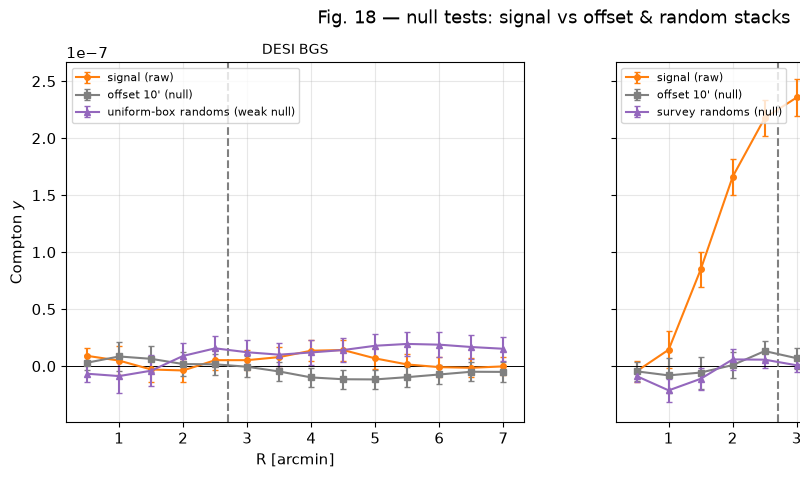

Why we do not use a rotation null:
  LS10 y_AP, cutouts as-is        = +2.286832e-07
  LS10 y_AP, cutouts rotated 90*k = +2.310843e-07   (1.0% away)
  The rotated "null" returns the signal. The CAP filter depends on each pixel only
  through its distance from the centre, and a 90-degree rotation of a square, odd-sized
  stamp maps the radius grid onto itself -- so it cannot change the answer. (The residual
  ~1% is not the test working: it comes from the cos(dec) stretch that makes the radius
  grid slightly elliptical. Nulling a 14-sigma detection by 1% is not a null test.)

Both real nulls sit on zero while the LS10 signal rises to ~2.4e-07 — that is what a
null test passing looks like. The survey-random null is the meaningful one: its
positions come from the real geometry, so it measures the mean y that a CAP filter
picks up from the footprint itself — exactly the quantity profile() subtracts from the
LS10 signal everywhere else in this notebook. A uniform RA/Dec box cannot do that 

In [29]:
# --- Figure 18: null tests ---------------------------------------------------
# These curves are deliberately RAW (not background-subtracted): the point of a null test is to
# see the background, not to hide it. profile() would subtract the random stack from the LS10
# signal, and the random null would then be zero by construction — which tests nothing.
NULL_OFFSET_ARCMIN = 10.0     # comfortably outside the largest ring (sqrt(2) x 7')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, s in zip(axes, [BGS, LS10]):
    st = get_stack('ymap_cib', s)
    if st is None: continue
    lab_jk = s['jk']
    mu, er = jackknife(st['prof'], labels=lab_jk)
    ax.errorbar(RADII, mu, er, color='C1', marker='o', ms=4, capsize=2, label='signal (raw)')

    # (1) offset positions: same sky, no galaxy at the centre. Offsetting in Dec avoids the
    #     cos(dec) stretch an RA offset would need, and every sample here stays well away
    #     from the poles.
    soff = stack_map('ymap_cib', s['RA'], s['DEC'] + NULL_OFFSET_ARCMIN/60.0)
    mo, eo = jackknife(soff['prof'], labels=lab_jk)
    ax.errorbar(RADII, mo, eo, color='0.5', marker='s', ms=4, capsize=2,
                label=f"offset {NULL_OFFSET_ARCMIN:g}' (null)")

    # (2) positions with no galaxy at all. Where the sample ships randoms we use them — they
    #     carry the true survey geometry. Otherwise fall back to a uniform RA/Dec box, which
    #     is a weaker null: it ignores the footprint and the mask entirely.
    if s.get('rand_ra') is not None:
        rr, rd, rlab, tag = s['rand_ra'], s['rand_dec'], s.get('rand_jk'), 'survey randoms (null)'
    else:
        n = min(len(s['RA']), 20000)
        rr = np.random.uniform(s['RA'].min(), s['RA'].max(), n*2)
        rd = np.degrees(np.arcsin(np.random.uniform(np.sin(np.radians(s['DEC'].min())),
                                                    np.sin(np.radians(s['DEC'].max())), n*2)))
        val = load_map('ymap').at(sky_coords(rr, rd), order=0); okm = np.isfinite(val)&(val!=0)
        rr, rd, rlab = rr[okm][:n], rd[okm][:n], None
        tag = 'uniform-box randoms (weak null)'
    srand = stack_map('ymap_cib', rr, rd)
    mrand, erand = jackknife(srand['prof'], labels=rlab)
    ax.errorbar(RADII, mrand, erand, color='C4', marker='^', ms=4, capsize=2, label=tag)

    ax.axhline(0, color='k', lw=.7); ax.axvline(R0, color='grey', ls='--')
    ax.set_xlabel('R [arcmin]'); ax.legend(fontsize=8, loc='upper left')
    ax.set_title(s['label'], fontsize=10)
axes[0].set_ylabel('Compton $y$')
fig.suptitle('Fig. 18 — null tests: signal vs offset & random stacks', y=0.99)
fig.subplots_adjust(top=0.88, bottom=0.13)
plt.savefig('sza_fig18_null.png', dpi=130)
plt.show()

# show explicitly that the rotation null cannot work, rather than just asserting it
_s = get_stack('ymap_cib', LS10)
_rot = stack_map('ymap_cib', LS10['RA'], LS10['DEC'], rotate=True)
_m0, _ = jackknife(_s['cap']); _m1, _ = jackknife(_rot['cap'])
print('Why we do not use a rotation null:')
print(f'  LS10 y_AP, cutouts as-is        = {_m0:+.6e}')
print(f'  LS10 y_AP, cutouts rotated 90*k = {_m1:+.6e}   ({100*abs(_m1/_m0-1):.1f}% away)')
print('  The rotated "null" returns the signal. The CAP filter depends on each pixel only')
print('  through its distance from the centre, and a 90-degree rotation of a square, odd-sized')
print('  stamp maps the radius grid onto itself -- so it cannot change the answer. (The residual')
print('  ~1% is not the test working: it comes from the cos(dec) stretch that makes the radius')
print('  grid slightly elliptical. Nulling a 14-sigma detection by 1% is not a null test.)\n')
print('Both real nulls sit on zero while the LS10 signal rises to ~2.4e-07 — that is what a')
print('null test passing looks like. The survey-random null is the meaningful one: its')
print('positions come from the real geometry, so it measures the mean y that a CAP filter')
print('picks up from the footprint itself — exactly the quantity profile() subtracts from the')
print('LS10 signal everywhere else in this notebook. A uniform RA/Dec box cannot do that job.')

## B. Binned radial profiles (Figures 19 & 20)

The radial profiles split into the six mass bins — for the single frequencies (Fig. 19) and for the ILC
maps (Fig. 20). Higher-mass bins show a stronger, more extended signal.

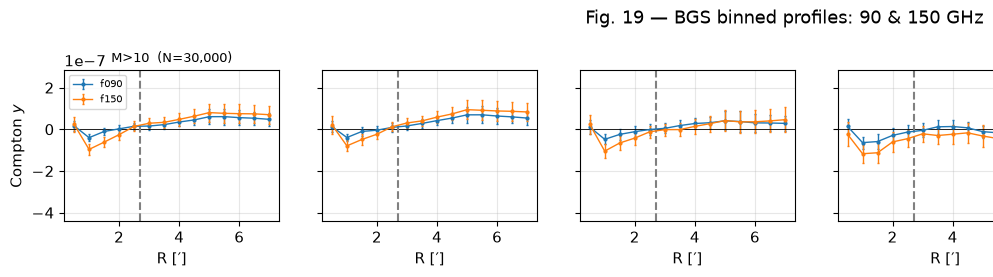

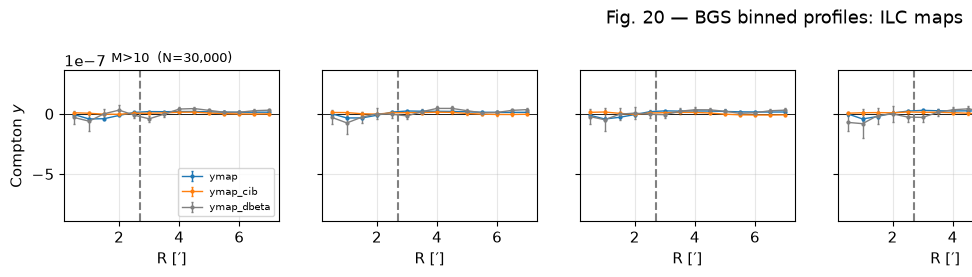

In [30]:
# --- Figures 19 & 20: binned radial profiles ---------------------------------
def binned_profiles(names, title, fname, sample=None):
    sample = BGS if sample is None else sample
    fig, axes = plt.subplots(1, len(MASS_CUTS), figsize=(16, 2.9), sharey=True)
    any_ok = False
    for ax, mc in zip(axes, MASS_CUTS):
        mask = sample['LOGMSTAR'] > mc
        for name, col in names:
            s = get_stack(name, sample)
            if s is None: continue
            any_ok = True; mu, er = profile(s, mask, sample=sample)
            ax.errorbar(RADII, mu, er, color=col, marker='.', ms=4, capsize=1, lw=1, label=name)
        ax.axhline(0,color='k',lw=.6); ax.axvline(R0,color='grey',ls='--')
        ax.set_title(f'M>{mc:g}  (N={int(mask.sum()):,})', fontsize=9)
        ax.set_xlabel('R [′]')
    axes[0].set_ylabel('Compton $y$'); axes[0].legend(fontsize=7)
    fig.suptitle(title, y=0.99)
    # Reserve room for the suptitle and x-labels inside the canvas. Two things to know here:
    # we do NOT use bbox_inches='tight' (for a wide multi-panel figure it computes an
    # artist-union bbox narrower than the canvas and silently crops the right-hand panels off
    # the saved file), and we use subplots_adjust rather than tight_layout because the latter
    # asks the renderer for every artist's bbox, which raises if a mass bin happens to be empty.
    fig.subplots_adjust(top=0.78, bottom=0.26, left=0.05, right=0.99)
    if any_ok: plt.savefig(fname, dpi=130)
    plt.show()

binned_profiles([('f090','C0'),('f150','C1')], 'Fig. 19 — BGS binned profiles: 90 & 150 GHz', 'sza_fig19_binned_freq.png')
binned_profiles([('ymap','C0'),('ymap_cib','C1'),('ymap_dbeta','0.5')],
                'Fig. 20 — BGS binned profiles: ILC maps', 'sza_fig20_binned_ilc.png')

## C. Sensitivity to the CIB model (Figures 21 & 22)

The deprojected maps depend on two assumptions: the CIB spectral index $\beta$ and temperature
$T_{\rm CIB}$. Repeating the profile with different deprojection maps shows how much this matters — for
well-behaved samples, very little near the aperture.

  [ymap_cib_b16] loaded  shape=(10320, 43200)  (y)


  [ymap_cib_T24] loaded  shape=(10320, 43200)  (y)


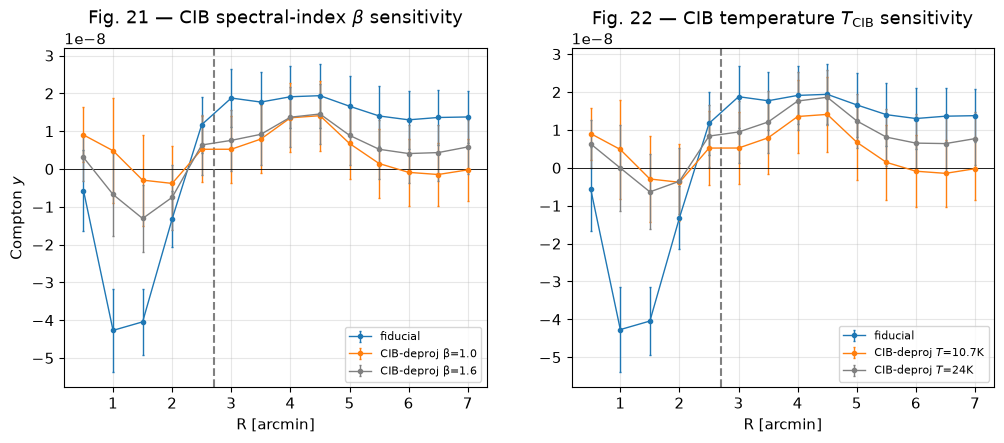

In [31]:
# --- Figures 21 & 22: CIB spectral-index and temperature sensitivity ---------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
# Fig 21: beta sensitivity (fiducial cib beta=1.0 vs beta=1.6)
for name, lab, col in [('ymap','fiducial','C0'), ('ymap_cib','CIB-deproj β=1.0','C1'),
                       ('ymap_cib_b16','CIB-deproj β=1.6','0.5')]:
    s = get_stack(name)
    if s is None: continue
    mu, er = profile(s); axes[0].errorbar(RADII, mu, er, color=col, marker='.', capsize=1, lw=1, label=lab)
axes[0].axhline(0,color='k',lw=.6); axes[0].axvline(R0,color='grey',ls='--')
axes[0].set_title('Fig. 21 — CIB spectral-index $\\beta$ sensitivity'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('R [arcmin]'); axes[0].set_ylabel('Compton $y$')
# Fig 22: T_CIB sensitivity (T=10.7 vs T=24)
for name, lab, col in [('ymap','fiducial','C0'), ('ymap_cib','CIB-deproj $T$=10.7K','C1'),
                       ('ymap_cib_T24','CIB-deproj $T$=24K','0.5')]:
    s = get_stack(name)
    if s is None: continue
    mu, er = profile(s); axes[1].errorbar(RADII, mu, er, color=col, marker='.', capsize=1, lw=1, label=lab)
axes[1].axhline(0,color='k',lw=.6); axes[1].axvline(R0,color='grey',ls='--')
axes[1].set_title('Fig. 22 — CIB temperature $T_{\\rm CIB}$ sensitivity'); axes[1].legend(fontsize=8)
axes[1].set_xlabel('R [arcmin]')
plt.savefig('sza_fig21_22_cib_sensitivity.png', dpi=130, bbox_inches='tight'); plt.show()

# Part 5 — Exercises

Work these with the notebook running (the data are already loaded).

1. **Signal-to-noise scaling.** Re-run the fiducial $y$-map stack with `MAX_SOURCES` set to 5 000, 10 000
   and 30 000. Plot the S/N of $\bar y_{\rm AP}$ versus $\sqrt{N_{\rm src}}$. Does it follow the expected
   $\propto\sqrt{N}$ law? What S/N would the **full** 1.6 M sample give?

2. **The compensated filter.** Change the ring definition so the outer radius is $2R$ instead of
   $\sqrt2\,R$. Recompute a full-sample $y_{\rm AP}$. Why does an *unequal-area* ring reintroduce
   sensitivity to a flat background? (Check `kern.sum()`.)

3. **Frequency scaling of dust.** Using the 220 GHz profile and `dust_f`, predict the dust contribution at
   90 vs 150 GHz for $\beta=1.2$ and $\beta=2.0$. Which frequency is more contaminated, and by how much?

4. **Mass trend.** Fit a power law $\bar y_{\rm AP}\propto M_*^{\,p}$ to the Fig. 12 CIB-deprojected points.
   Compare $p$ to the self-similar expectation for $Y\propto M^{5/3}$ (recall N10b) — remember these are
   *stellar* masses, not halo masses. Then refit including the LS10 point. How much does one point at the
   high-mass end move $p$? Should it, given that it carries a different stellar-mass estimator?

5. **Optical depth.** Convert your $\bar y$ for the `M>11` bin to $\tau$ with the SIMBA relation. Propagate
   the error on $\ln\tau_0$ and $m$ (Table values) with a small Monte Carlo. Is your $\tau$ consistent with
   the kSZ value?

6. **A different aperture.** Repeat the `M>10.75` measurement at $R_{\rm AP}=2.1'$ and $4.0'$. How does the
   central-dust bias (90 vs 150 GHz difference) change with aperture size?

7. **What the randoms are worth.** For the LS10 sample, recompute the Fig. 5 profile three ways: (a) as
   plotted, (b) with the random background *not* subtracted, and (c) with `labels=None` forced in
   `jackknife()` so the errors come from permutation groups. Which change moves the central value, and
   which moves the error bar? Roughly how large is the footprint's mean $y$ compared to the signal?

8. **Region count.** Vary `N_SKY_REGIONS` over 20, 50, 100, 200 and re-plot the LS10 $y_{\rm AP}$ error.
   Jackknife needs regions large enough to contain the correlations you care about, but numerous enough
   to estimate a variance. Where does the error bar stabilise, and what does that scale correspond to on
   the sky at $z\approx0.26$?

9. **Designing a null test.** Appendix A shows that rotating the cutouts cannot null a CAP
   measurement. (a) Prove it in two lines with `np.rot90` and the `disk`/`ring` masks from §4.
   (b) For which of the filters in this notebook *would* a rotation null be a real test — CAP,
   ring−ring, or neither? (c) The offset null uses 10′. Re-run it at 3′ and 20′: at what offset
   does the "null" stop being null, and what does that tell you about the extent of the gas?

# Summary

- We measured the **stacked thermal SZ signal** around galaxies using public ACT DR6+*Planck* maps,
  implementing the full pipeline — cutouts, **compensated aperture photometry**, stacking, radial
  profiles and jackknife errors — from scratch.
- We ran it on **two samples**: the flux-limited DESI DR1 BGS, and the volume-limited LS10 BGS
  ($\log_{10}M_*>11.5$) of Comparat et al. 2025, which reaches ~0.25 dex higher in stellar mass and
  ships a **random catalogue**.
- The **Compton-$y$** signal grows with stellar mass and is detected in the ILC and 90 GHz maps; the
  150 GHz map is biased low at small radii by **dust**, confirmed by the near-null **220 GHz** stack.
- We characterised the systematics that define this field's frontier: **CIB deprojection** (ILC variants),
  **ring-ring** large-scale CIB tests, **220 GHz dust removal**, and **radio** contamination via NVSS —
  which, for a footprint reaching south of Dec $=-40°$, means confronting the fact that NVSS simply
  **does not cover** part of our sample.
- The randoms did three jobs: **background subtraction** (making the measurement an excess above the
  footprint mean rather than an absolute $y$), a **null test with the true survey geometry**, and
  **sky-patch jackknife regions**, which raise the error bars because they finally include sample variance.
- We converted $\bar y$ to a gas **optical depth** with a simulation-calibrated $y$–$\tau$ relation and
  compared it to the independent **pairwise-kSZ** measurement — for the BGS bins where such a measurement
  exists. For LS10 it does not, and we plotted the prediction as a prediction.
- Everything used **only public data**; a subsample keeps the notebook fast, and `FULL_RUN=True` reproduces
  the literature-scale signal-to-noise.

**Key equations:** $\delta T/T=f_{\rm SZ}\,y$ · $y=\frac{\sigma_T}{m_ec^2}\!\int\! n_ek_BT_e\,dl$ ·
$\tau=\sigma_T\!\int\! n_e\,dl$ · $y_{\rm AP}$ (disk−ring) · $\ln\bar\tau=\ln\tau_0+m\ln(\bar y/\bar y_0)$.

**Next:** the *kinematic* SZ effect (companion kSZ analyses) measures $\tau$ directly from pairwise
velocities — combine it with the tSZ $\bar y$ here to separate gas **density** from **temperature**, and to
constrain feedback models of the circumgalactic medium. The same LS10 samples used here are measured in
projected $\Sigma_y(r_p)$ bins by the `sum_stat` pipeline, whose outputs feed the `hod_mod` halo-occupation
fits — that is how a stack like this one becomes a constraint on feedback.

# Closing the loop: the same sample, measured by `sum_stat`

The Summary above promised that "the same LS10 samples are measured in projected $\Sigma_y(r_p)$ bins
by the `sum_stat` pipeline". Those files now exist — nine volume-limited BGS samples, each stacked on
the same ACT DR6.02 NILC map, written as $\Sigma_y(r_p)$ in **comoving** Mpc with a 100-region
jackknife covariance. Here we read the one matching this notebook's LS10 sample and put it beside the
$y_{\rm AP}$ we measured in-kernel.

Two things are deliberately **not** the same between them, so do not expect the curves to overlie:

- **Different filter.** This notebook reports compensated aperture photometry $y_{\rm AP}(\theta)$ —
  a disk minus an equal-area ring, insensitive to the mean map level. `sum_stat` reports the *raw*
  annular profile $\Sigma_y(r_p)$, background-subtracted with the randoms. One is a high-pass filter
  of the other.
- **Different pipeline and binning.** Angular arcmin apertures at fixed $\langle z\rangle$ here;
  per-galaxy comoving-Mpc bins (each galaxy's own $D_M(z)$) in `sum_stat`.

What *should* agree: both are positive at small scales (hot gas around galaxies) and both fall to
consistent-with-zero at large separation once the background is removed.

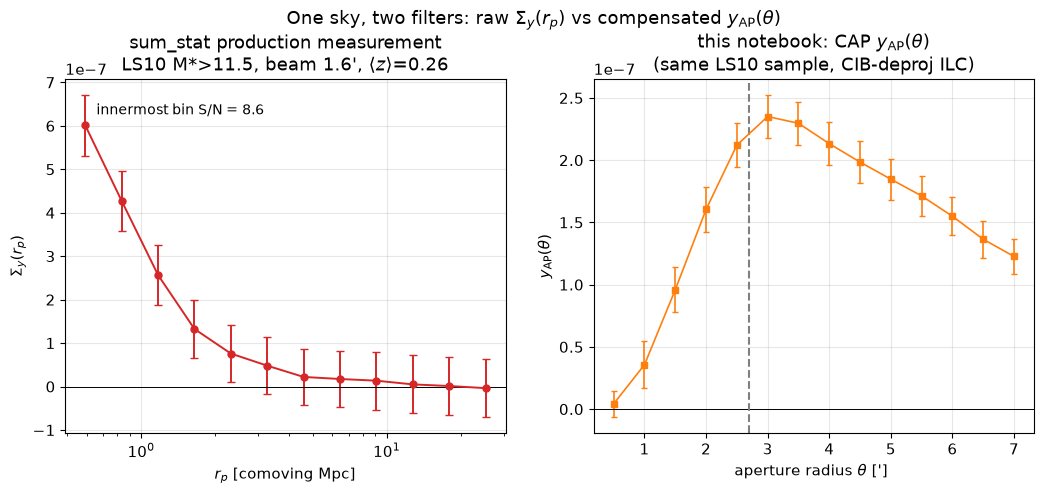

sum_stat Sigma_y: innermost bin +6.01e-07 +/- 7.0e-08 (S/N 8.6) at r_p=0.59 comoving Mpc
Across all nine LS10 samples (this session): S/N rises from ~2 below logM*~11 to 8.6 at
logM*>11.5. Below logM*~11 the signal is undetected AND the errors are flat with sample
size -- the measurement is limited by the map and cosmic variance, not by galaxy count,
so a deeper low-mass sample would not help. The sky-patch jackknife (not a permutation
jackknife) is what reports those errors honestly.


In [32]:
# --- read the sum_stat Sigma_y(r_p) for this notebook's LS10 M*>11.5 sample ---
import h5py, glob

# sum_stat writes here; guard so the notebook still runs without the local build tree
_SS_DIR = '/home/comparat/software/sum_stat/data/BGS_SZ'
_matches = glob.glob(f'{_SS_DIR}/{LS10_STEM}_joint_sz*.h5')
if _matches:
    with h5py.File(_matches[0]) as _f:
        _sid = list(_f['sz'].keys())[0]; _g = _f[f'sz/{_sid}']
        rp_ss   = _g['rp_centres'][:]                 # comoving Mpc
        sy_ss   = _g['sigma_y'][:]                     # dimensionless
        er_ss   = np.sqrt(np.diag(_g['cov'][:]))
        beam_ss = float(dict(_g.attrs).get('beam_fwhm_arcmin', np.nan))
        z_ss    = float(dict(_g.attrs).get('z_eff_sz', np.nan))

    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
    # left: sum_stat Sigma_y(r_p)
    ax[0].errorbar(rp_ss, sy_ss, er_ss, marker='o', ms=5, capsize=3, color='C3', lw=1.4)
    ax[0].axhline(0, color='k', lw=.7)
    ax[0].set_xscale('log'); ax[0].set_xlabel(r'$r_p$ [comoving Mpc]')
    ax[0].set_ylabel(r'$\Sigma_y(r_p)$'); ax[0].set_title(
        f'sum_stat production measurement\nLS10 M*>11.5, beam {beam_ss:g}\', $\\langle z\\rangle$={z_ss:.2f}')
    sn0 = sy_ss[0] / er_ss[0]
    ax[0].annotate(f'innermost bin S/N = {sn0:.1f}', (rp_ss[0], sy_ss[0]),
                   textcoords='offset points', xytext=(8, 8), fontsize=10)

    # right: this notebook's own y_AP(theta) on the same LS10 sample, for contrast
    st = get_stack('ymap_cib', LS10)
    mu_ap, er_ap = profile(st, sample=LS10)
    ax[1].errorbar(RADII, mu_ap, er_ap, marker='s', ms=4, capsize=2, color='C1', lw=1.2)
    ax[1].axhline(0, color='k', lw=.7); ax[1].axvline(R0, color='grey', ls='--')
    ax[1].set_xlabel(r"aperture radius $\theta$ ['] "); ax[1].set_ylabel(r'$y_{\rm AP}(\theta)$')
    ax[1].set_title('this notebook: CAP $y_{\\rm AP}(\\theta)$\n(same LS10 sample, CIB-deproj ILC)')
    fig.suptitle('One sky, two filters: raw $\\Sigma_y(r_p)$ vs compensated $y_{\\rm AP}(\\theta)$', y=1.03)
    plt.savefig('sza_fig23_sumstat_sigma_y.png', dpi=130, bbox_inches='tight'); plt.show()

    print(f'sum_stat Sigma_y: innermost bin {sy_ss[0]:+.2e} +/- {er_ss[0]:.1e} '
          f'(S/N {sn0:.1f}) at r_p={rp_ss[0]:.2f} comoving Mpc')
    print('Across all nine LS10 samples (this session): S/N rises from ~2 below logM*~11 to 8.6 at')
    print('logM*>11.5. Below logM*~11 the signal is undetected AND the errors are flat with sample')
    print('size -- the measurement is limited by the map and cosmic variance, not by galaxy count,')
    print('so a deeper low-mass sample would not help. The sky-patch jackknife (not a permutation')
    print('jackknife) is what reports those errors honestly.')
else:
    print(f'No sum_stat SZ file found under {_SS_DIR} for {LS10_STEM}.')
    print('Run:  python sum_stat/scripts/measure_joint_sumstat.py --survey bgs --stats SZ ...')
    print('This section is optional; the rest of the notebook is self-contained.')